## Инициализация

In [282]:
import matplotlib.pyplot as plt
import random
import numpy as np
import os
import json
import torch
import copy

from tqdm import tqdm

from torchinfo import summary

import torchvision
from torchvision.transforms import InterpolationMode
import torchvision.transforms.v2 as tfs
from torchvision.datasets import ImageFolder
import torch.utils.data as data

import albumentations as A
import albumentations.augmentations as F
from albumentations.pytorch import ToTensorV2

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [283]:
dataset_label = 'dataset'
train_label = 'train'
test_label = 'test'
format_label = 'format.json'

train_directory = os.path.join(dataset_label, train_label)
test_directory = os.path.join(dataset_label, test_label)
format_directory = os.path.join(dataset_label, format_label)

In [284]:
train_count = 0
for _, _, files in os.walk(train_directory):
    train_count += len(files)

test_count = 0
for _, _, files in os.walk(test_directory):
    test_count += len(files)

In [285]:
with open(format_directory, 'r') as file:
    classes = json.load(file)

classes = list(classes.values())

In [286]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

Используется устройство: cpu


## Базовые функции и классы

In [287]:
class AlbumentationsTransform:
    def __init__(self, albumentations_transform):
        self.albumentations_transform = albumentations_transform

    def __call__(self, img):
        img = np.array(img)
        augmented = self.albumentations_transform(image=img)
        return augmented['image']

In [288]:
def loss_model(model, loss_func, data):
  model.eval()
  Q = 0
  count = 0

  for x, y in data:
    x = x.to(device)
    y = y.to(device)

    with torch.no_grad():
      p = model(x)
      loss = loss_func(p, y)
      Q += loss.item()
      count += 1

  Q /= count

  return Q

def accuracy_model(model, device, data):
  model.eval()
  Q = 0

  for x, y in data:
    x = x.to(device)
    y = y.to(device)

    with torch.no_grad():
      p = model(x)
      p = torch.argmax(p, dim=1)
      Q += torch.sum(p == y).item()

  count = len(data.dataset)

  Q /= count
  
  return Q

In [289]:
def train_model(model, device, train_data, train_data_val, optimizer, loss_func, epochs):
  model.to(device)
  acc_lst_val = []
  acc_lst = []
  for _e in range(epochs):
    model.train()
    loss_mean = 0
    lm_count = 0
    train_tqdm = tqdm(train_data, leave=False)

    # Обучение на 1 батче
    for x_train, y_train in train_tqdm:
      x_train = x_train.to(device)
      y_train = y_train.to(device)

      predict = model(x_train)
      loss = loss_func(predict, y_train)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # обновление среднего по формуле
      lm_count += 1
      loss_mean = 1 / lm_count * loss.item() + (1 - 1 / lm_count) * loss_mean
      train_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss: {loss_mean:.4f}")

    # валидация
    # Q_val = loss_model(model, loss_func, train_data_val)

    train_acc = accuracy_model(model, device, train_data)
    val_acc = accuracy_model(model, device, train_data_val)

    acc_lst.append(train_acc)
    acc_lst_val.append(val_acc)

    print(f'Epoch [{_e+1}/{epochs}] | acc_train={train_acc:.3f}, acc_val={val_acc:.3f}')
  return model, acc_lst, acc_lst_val

In [290]:
def show_loss(loss_lst, loss_lst_val):
  plt.plot(loss_lst, label='predict')
  plt.plot(loss_lst_val, label='real')
  plt.legend()
  plt.grid()
  plt.show()

In [291]:
def split_data(transform, train_size=0.8, batch_size=100, album=False):
    if album:
        transform = AlbumentationsTransform(transform)
    dataset_train = ImageFolder(train_directory, transform=transform)

    train_size = int(train_size * len(dataset_train))
    val_size = len(dataset_train) - train_size
    d_train, d_val = data.random_split(dataset_train, [train_size, val_size])

    train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True)
    train_data_val = data.DataLoader(d_val, batch_size=batch_size, shuffle=False)

    d_test = ImageFolder(test_directory, transform=transform)
    test_data = data.DataLoader(d_test, batch_size=batch_size, shuffle=False)

    return train_data, train_data_val, test_data

## Пользовательская нейронная сеть

### Начальная модель

In [292]:
class ModelNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        torch.nn.Conv2d(
            in_channels=3, out_channels=6, kernel_size=5, padding=2), # (batch, 6, 200, 200)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 6, 100, 100)

        torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=2), # (batch, 16, 100, 100)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 16, 50, 50)

        torch.nn.Conv2d(
            in_channels=16, out_channels=16, kernel_size=5, padding=0), # (batch, 16, 46, 46)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 16, 23, 23)

        nn.Flatten(),

        torch.nn.Linear(23 * 23 * 16, 120),
        torch.nn.ReLU(),
        torch.nn.Linear(120, 84),
        torch.nn.ReLU(),
        torch.nn.Linear(84, len(classes))
    )

  def forward(self, x):
    return self.layers(x)

In [293]:
model = ModelNN()
model = model.to(device)
sum(p.numel() for p in model.parameters())

1035507

In [294]:
transforms = tfs.Compose(
    [
        tfs.ToImage(),
        tfs.ToDtype(torch.float32, scale=True)
    ]
)

train_size = 0.8
batch_size = 100
album = False

In [295]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [296]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [297]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.375, acc_val=0.379


Epoch [2/20] | acc_train=0.547, acc_val=0.533


Epoch [3/20] | acc_train=0.573, acc_val=0.542


Epoch [4/20] | acc_train=0.609, acc_val=0.596


Epoch [5/20] | acc_train=0.677, acc_val=0.704


...

Epoch [16/20] | acc_train=0.972, acc_val=0.933


Epoch [17/20] | acc_train=0.980, acc_val=0.954


Epoch [18/20] | acc_train=0.993, acc_val=0.954


Epoch [19/20] | acc_train=0.993, acc_val=0.954


Epoch [20/20] | acc_train=0.985, acc_val=0.925


0.93


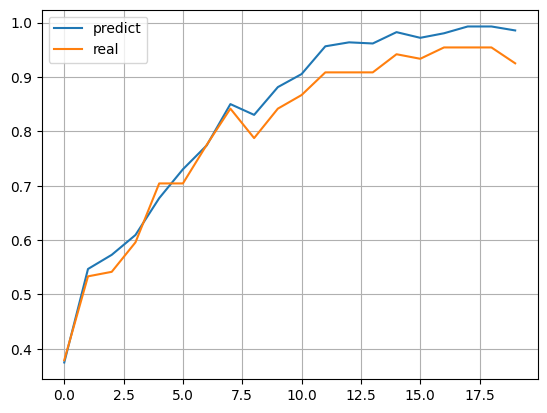

In [298]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Разное кол-во слоев

#### Больше сверточных слоев

In [299]:
class ModelNN_cnn5(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      torch.nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2), # (batch, 6, 200, 200)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=2, stride=2),                             # (batch, 6, 100, 100)

      torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=2), # (batch, 16, 100, 100)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=2, stride=2),                              # (batch, 16, 50, 50)

      torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=5, padding=0), # (batch, 16, 46, 46)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=2, stride=2),                               # (batch, 16, 23, 23)

      # Новый сверточный слой 1
      torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1), # (batch, 32, 23, 23)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=2, stride=2),                               # (batch, 32, 11, 11)

      # Новый сверточный слой 2
      torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # (batch, 64, 11, 11)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=2, stride=2),                               # (batch, 64, 5, 5)

      nn.Flatten(),

      torch.nn.Linear(5 * 5 * 64, 120),
      torch.nn.ReLU(),
      torch.nn.Linear(120, 84),
      torch.nn.ReLU(),
      torch.nn.Linear(84, len(classes))
    )

  def forward(self, x):
    return self.layers(x)


Мы увеличили кол-во сверточных слоев, однако кол-во параметров у модели уменьшилось в 5 раз

In [300]:
model = ModelNN_cnn5()
model = model.to(device)
sum(p.numel() for p in model.parameters())

234963

In [301]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [303]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.336, acc_val=0.321


Epoch [2/20] | acc_train=0.350, acc_val=0.333


Epoch [3/20] | acc_train=0.559, acc_val=0.558


Epoch [4/20] | acc_train=0.546, acc_val=0.550


Epoch [5/20] | acc_train=0.664, acc_val=0.629


...

Epoch [16/20] | acc_train=0.980, acc_val=0.954


Epoch [17/20] | acc_train=0.951, acc_val=0.938


Epoch [18/20] | acc_train=0.992, acc_val=0.967


Epoch [19/20] | acc_train=0.984, acc_val=0.950


Epoch [20/20] | acc_train=0.997, acc_val=0.975


0.9766666666666667


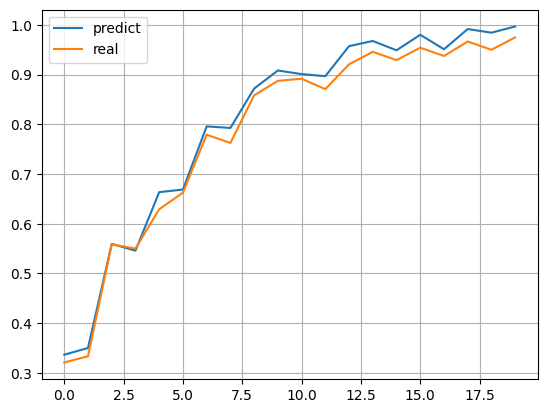

In [304]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

Мы видим, что, несмотря на меньшее кол-во параметров, модель с большим кол-во сверточных слоев справилась с задачей лучше. Можно предположить, что начальная модель также может дойти до такой же точности, т.к. по графику можно заметить, что модель не дошла до плато/переобучения.

Из эксперимента можно утверждать: увеличение количества свёрточных слоев позволяет модели находить больее сложные и абстрактные признаки, что увеличивает ее точность.

#### Больше линейных слоев

In [ ]:
class ModelNN_fc5(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      torch.nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2),  # (batch, 6, 200, 200)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=2, stride=2),  # (batch, 6, 100, 100)

      torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=2),  # (batch, 16, 100, 100)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=2, stride=2),  # (batch, 16, 50, 50)

      torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=5, padding=0),  # (batch, 16, 46, 46)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=2, stride=2),  # (batch, 16, 23, 23)

      nn.Flatten(),

      torch.nn.Linear(23 * 23 * 16, 120),
      torch.nn.ReLU(),

      # Дополнительные линейные слои
      torch.nn.Linear(120, 100),
      torch.nn.ReLU(),
      torch.nn.Linear(100, 90),
      torch.nn.ReLU(),

      torch.nn.Linear(90, 84),
      torch.nn.ReLU(),

      torch.nn.Linear(84, 50),
      torch.nn.ReLU(),

      torch.nn.Linear(50, len(classes))
    )

  def forward(self, x):
    return self.layers(x)


Кол-во параметров практически неизменилось

In [ ]:
model = ModelNN_fc5()
model = model.to(device)
sum(p.numel() for p in model.parameters())

1058325

In [ ]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

В данной модели линейный классификатор является достаточно сложных по структуре, однако тот на вход получает небольшое кол-во признаков, из-за чего модель "путается" и точность падает.

Вывод из эксперимента: для задач подобного масштаба, линейный классификатор должен быть небольшим.

In [ ]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

In [ ]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Число карт признаков в слоях

#### Больше

In [305]:
class ModelNN_maps64(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      torch.nn.Conv2d(
          in_channels=3, out_channels=16, kernel_size=5, padding=2),  # (batch, 16, 200, 200)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=2, stride=2),                   # (batch, 16, 100, 100)

      torch.nn.Conv2d(
          in_channels=16, out_channels=48, kernel_size=5, padding=2),  # (batch, 48, 100, 100)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=2, stride=2),                    # (batch, 48, 50, 50)

      torch.nn.Conv2d(
          in_channels=48, out_channels=64, kernel_size=5, padding=0),  # (batch, 64, 46, 46)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=2, stride=2),                    # (batch, 64, 23, 23)

      nn.Flatten(),

      torch.nn.Linear(23 * 23 * 64, 120),  # изменился размер входа
      torch.nn.ReLU(),
      torch.nn.Linear(120, 84),
      torch.nn.ReLU(),
      torch.nn.Linear(84, len(classes))
    )

  def forward(self, x):
    return self.layers(x)


In [306]:
model = ModelNN_maps64()
model = model.to(device)
sum(p.numel() for p in model.parameters())

4170587

In [307]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

Модель имеет идентичную точность, что и начальная модель, однако имеет в 4 раза больше параметров.

Также присутствуют признаки начала переобучения: ошибка на тренировочных данных значительно выше чем на валидационных. Похожая ситуация была и у начальной модели, на разница была не столь существенной.

In [308]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.439, acc_val=0.458


Epoch [2/20] | acc_train=0.572, acc_val=0.550


Epoch [3/20] | acc_train=0.671, acc_val=0.642


Epoch [4/20] | acc_train=0.772, acc_val=0.713


Epoch [5/20] | acc_train=0.859, acc_val=0.838


...

Epoch [16/20] | acc_train=0.999, acc_val=0.963


Epoch [17/20] | acc_train=0.990, acc_val=0.950


Epoch [18/20] | acc_train=0.997, acc_val=0.954


Epoch [19/20] | acc_train=0.996, acc_val=0.933


Epoch [20/20] | acc_train=1.000, acc_val=0.963


0.9633333333333334


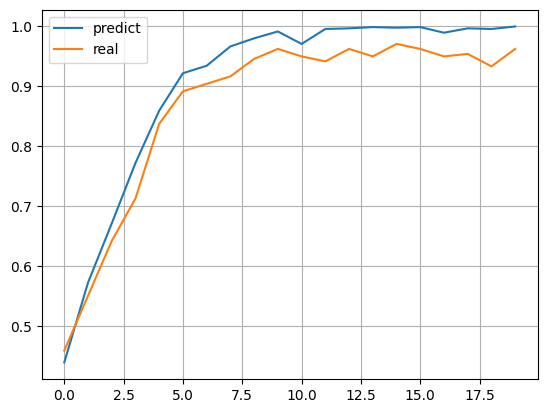

In [309]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### Меньше

In [310]:
class ModelNN_maps8(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            torch.nn.Conv2d(
                in_channels=3, out_channels=3, kernel_size=5, padding=2),  # (batch, 3, 200, 200)
            torch.nn.ReLU(),
            torch.nn.AvgPool2d(kernel_size=2, stride=2),                  # (batch, 3, 100, 100)

            torch.nn.Conv2d(
                in_channels=3, out_channels=8, kernel_size=5, padding=2),  # (batch, 8, 100, 100)
            torch.nn.ReLU(),
            torch.nn.AvgPool2d(kernel_size=2, stride=2),                  # (batch, 8, 50, 50)

            torch.nn.Conv2d(
                in_channels=8, out_channels=8, kernel_size=5, padding=0),  # (batch, 8, 46, 46)
            torch.nn.ReLU(),
            torch.nn.AvgPool2d(kernel_size=2, stride=2),                  # (batch, 8, 23, 23)

            nn.Flatten(),

            torch.nn.Linear(23 * 23 * 8, 120),  # размер входа изменился
            torch.nn.ReLU(),
            torch.nn.Linear(120, 84),
            torch.nn.ReLU(),
            torch.nn.Linear(84, len(classes))
        )

    def forward(self, x):
        return self.layers(x)


In [311]:
model = ModelNN_maps8()
model = model.to(device)
sum(p.numel() for p in model.parameters())

520823

In [312]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [313]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.522, acc_val=0.475


Epoch [2/20] | acc_train=0.529, acc_val=0.496


Epoch [3/20] | acc_train=0.617, acc_val=0.592


Epoch [4/20] | acc_train=0.675, acc_val=0.642


Epoch [5/20] | acc_train=0.748, acc_val=0.721


...

Epoch [16/20] | acc_train=0.977, acc_val=0.946


Epoch [17/20] | acc_train=0.989, acc_val=0.942


Epoch [18/20] | acc_train=0.991, acc_val=0.942


Epoch [19/20] | acc_train=0.997, acc_val=0.950


Epoch [20/20] | acc_train=0.997, acc_val=0.942


0.9233333333333333


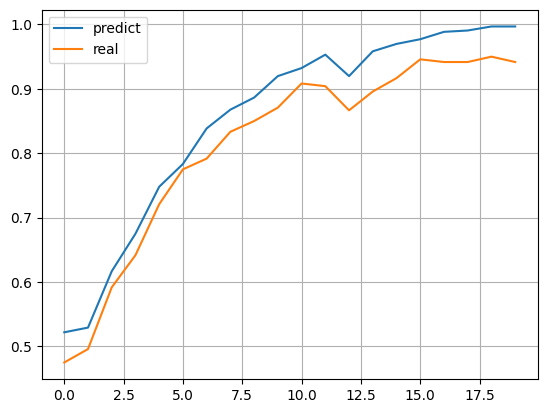

In [314]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Функции активации

#### LeakyReLU

In [315]:
class ModelNN_lrelu(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            torch.nn.Conv2d(
                in_channels=3, out_channels=3, kernel_size=5, padding=2),  # (batch, 3, 200, 200)
            torch.nn.LeakyReLU(),
            torch.nn.AvgPool2d(kernel_size=2, stride=2),                  # (batch, 3, 100, 100)

            torch.nn.Conv2d(
                in_channels=3, out_channels=8, kernel_size=5, padding=2),  # (batch, 8, 100, 100)
            torch.nn.LeakyReLU(),
            torch.nn.AvgPool2d(kernel_size=2, stride=2),                  # (batch, 8, 50, 50)

            torch.nn.Conv2d(
                in_channels=8, out_channels=8, kernel_size=5, padding=0),  # (batch, 8, 46, 46)
            torch.nn.LeakyReLU(),
            torch.nn.AvgPool2d(kernel_size=2, stride=2),                  # (batch, 8, 23, 23)

            nn.Flatten(),

            torch.nn.Linear(23 * 23 * 8, 120),  # размер входа изменился
            torch.nn.LeakyReLU(),
            torch.nn.Linear(120, 84),
            torch.nn.LeakyReLU(),
            torch.nn.Linear(84, len(classes))
        )

    def forward(self, x):
        return self.layers(x)


In [316]:
model = ModelNN_lrelu()
model = model.to(device)
sum(p.numel() for p in model.parameters())

520823

In [317]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [318]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.336, acc_val=0.321


Epoch [2/20] | acc_train=0.402, acc_val=0.379


Epoch [3/20] | acc_train=0.521, acc_val=0.475


Epoch [4/20] | acc_train=0.602, acc_val=0.588


Epoch [5/20] | acc_train=0.572, acc_val=0.562


...

Epoch [16/20] | acc_train=0.957, acc_val=0.929


Epoch [17/20] | acc_train=0.972, acc_val=0.912


Epoch [18/20] | acc_train=0.980, acc_val=0.946


Epoch [19/20] | acc_train=0.978, acc_val=0.954


Epoch [20/20] | acc_train=0.990, acc_val=0.950


0.9333333333333333


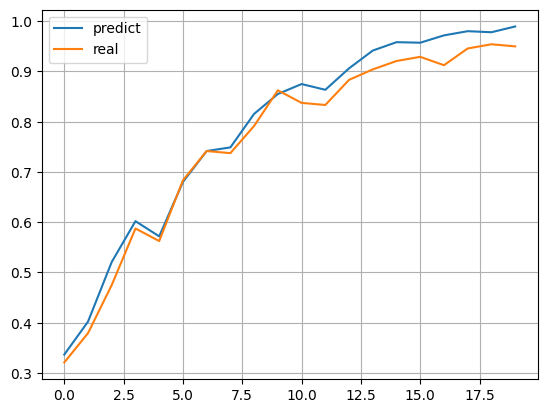

In [319]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### tanh

In [320]:
class ModelNN_tanh(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        torch.nn.Conv2d(
            in_channels=3, out_channels=6, kernel_size=5, padding=2), # (batch, 6, 200, 200)
        torch.nn.Tanh(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 6, 100, 100)

        torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=2), # (batch, 16, 100, 100)
        torch.nn.Tanh(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 16, 50, 50)

        torch.nn.Conv2d(
            in_channels=16, out_channels=16, kernel_size=5, padding=0), # (batch, 16, 46, 46)
        torch.nn.Tanh(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 16, 23, 23)

        nn.Flatten(),

        torch.nn.Linear(23 * 23 * 16, 120),
        torch.nn.Tanh(),
        torch.nn.Linear(120, 84),
        torch.nn.Tanh(),
        torch.nn.Linear(84, len(classes))
    )

  def forward(self, x):
    return self.layers(x)

In [321]:
model = ModelNN_tanh()
model = model.to(device)
sum(p.numel() for p in model.parameters())

1035507

In [322]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [323]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.567, acc_val=0.512


Epoch [2/20] | acc_train=0.602, acc_val=0.567


Epoch [3/20] | acc_train=0.685, acc_val=0.646


Epoch [4/20] | acc_train=0.721, acc_val=0.675


Epoch [5/20] | acc_train=0.778, acc_val=0.746


...

Epoch [16/20] | acc_train=0.976, acc_val=0.933


Epoch [17/20] | acc_train=0.970, acc_val=0.929


Epoch [18/20] | acc_train=0.965, acc_val=0.912


Epoch [19/20] | acc_train=0.960, acc_val=0.925


Epoch [20/20] | acc_train=0.965, acc_val=0.929


0.8933333333333333


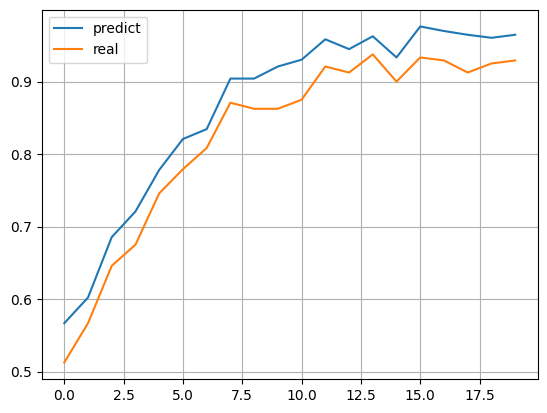

In [324]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Размер ядра свертки

#### kernel_size=3

In [325]:
class ModelNN_ks3(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        torch.nn.Conv2d(
            in_channels=3, out_channels=6, kernel_size=3, padding=1), # (batch, 6, 200, 200)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 6, 100, 100)

        torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=3, padding=1), # (batch, 16, 100, 100)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 16, 50, 50)

        torch.nn.Conv2d(
            in_channels=16, out_channels=16, kernel_size=3, padding=0), # (batch, 16, 46, 46)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 16, 23, 23)

        nn.Flatten(),

        torch.nn.Linear(24 * 24 * 16, 120),
        torch.nn.ReLU(),
        torch.nn.Linear(120, 84),
        torch.nn.ReLU(),
        torch.nn.Linear(84, len(classes))
    )

  def forward(self, x):
    return self.layers(x)

In [326]:
model = ModelNN_ks3()
model = model.to(device)
sum(p.numel() for p in model.parameters())

1119827

In [327]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [328]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.501, acc_val=0.475


Epoch [2/20] | acc_train=0.525, acc_val=0.475


Epoch [3/20] | acc_train=0.527, acc_val=0.508


Epoch [4/20] | acc_train=0.626, acc_val=0.567


Epoch [5/20] | acc_train=0.665, acc_val=0.625


...

Epoch [16/20] | acc_train=0.963, acc_val=0.900


Epoch [17/20] | acc_train=0.960, acc_val=0.896


Epoch [18/20] | acc_train=0.961, acc_val=0.921


Epoch [19/20] | acc_train=0.972, acc_val=0.912


Epoch [20/20] | acc_train=0.983, acc_val=0.954


0.9266666666666666


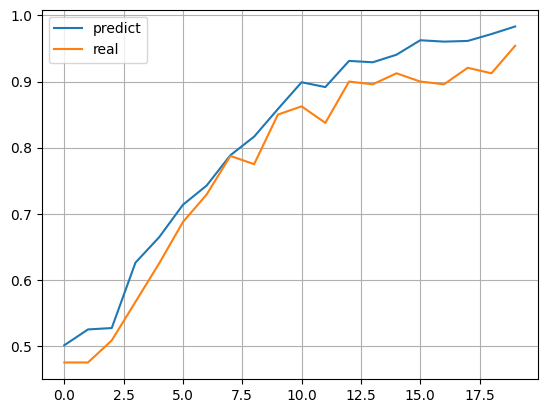

In [329]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### kernel_size=7

In [330]:
class ModelNN_ks7(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        torch.nn.Conv2d(
            in_channels=3, out_channels=6, kernel_size=7, padding=2), # (batch, 6, 200, 200)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 6, 100, 100)

        torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=7, padding=2), # (batch, 16, 100, 100)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 16, 50, 50)

        torch.nn.Conv2d(
            in_channels=16, out_channels=16, kernel_size=7, padding=0), # (batch, 16, 46, 46)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 16, 23, 23)

        nn.Flatten(),

        torch.nn.Linear(21 * 21 * 16, 120),
        torch.nn.ReLU(),
        torch.nn.Linear(120, 84),
        torch.nn.ReLU(),
        torch.nn.Linear(84, len(classes))
    )

  def forward(self, x):
    return self.layers(x)

In [331]:
model = ModelNN_ks7()
model = model.to(device)
sum(p.numel() for p in model.parameters())

875427

In [332]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [333]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.333, acc_val=0.333


Epoch [2/20] | acc_train=0.489, acc_val=0.467


Epoch [3/20] | acc_train=0.571, acc_val=0.533


Epoch [4/20] | acc_train=0.698, acc_val=0.650


Epoch [5/20] | acc_train=0.637, acc_val=0.621


...

Epoch [16/20] | acc_train=0.986, acc_val=0.946


Epoch [17/20] | acc_train=0.995, acc_val=0.954


Epoch [18/20] | acc_train=0.998, acc_val=0.963


Epoch [19/20] | acc_train=0.989, acc_val=0.954


Epoch [20/20] | acc_train=0.990, acc_val=0.954


0.95


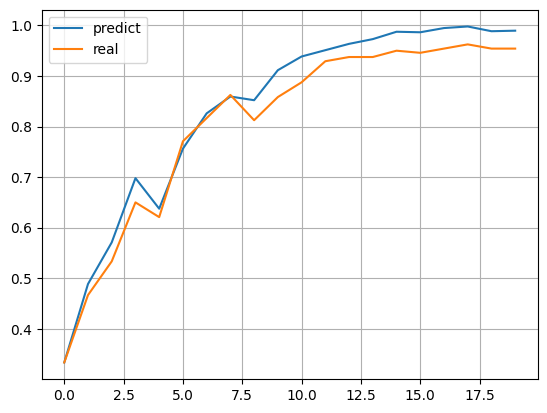

In [334]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Padding

#### padding=3

In [335]:
class ModelNN_p3(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        torch.nn.Conv2d(
            in_channels=3, out_channels=6, kernel_size=5, padding=3), # (batch, 6, 202, 202)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 6, 101, 101)

        torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=3), # (batch, 16, 103, 103)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 16, 51, 51)

        torch.nn.Conv2d(
            in_channels=16, out_channels=16, kernel_size=5, padding=3), # (batch, 16, 53, 53)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 16, 26, 26)

        nn.Flatten(),

        torch.nn.Linear(26 * 26 * 16, 120),
        torch.nn.ReLU(),
        torch.nn.Linear(120, 84),
        torch.nn.ReLU(),
        torch.nn.Linear(84, len(classes))
    )

  def forward(self, x):
    return self.layers(x)

In [336]:
model = ModelNN_p3()
model = model.to(device)
sum(p.numel() for p in model.parameters())

1317747

In [337]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [338]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.510, acc_val=0.479


Epoch [2/20] | acc_train=0.531, acc_val=0.487


Epoch [3/20] | acc_train=0.604, acc_val=0.571


Epoch [4/20] | acc_train=0.651, acc_val=0.662


Epoch [5/20] | acc_train=0.691, acc_val=0.662


...

Epoch [16/20] | acc_train=0.993, acc_val=0.946


Epoch [17/20] | acc_train=0.990, acc_val=0.938


Epoch [18/20] | acc_train=0.997, acc_val=0.942


Epoch [19/20] | acc_train=0.984, acc_val=0.938


Epoch [20/20] | acc_train=0.995, acc_val=0.958


0.9466666666666667


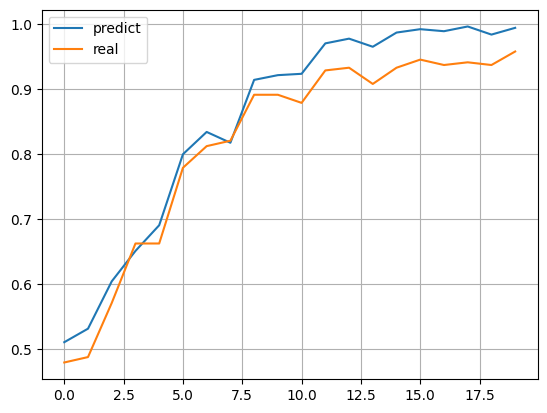

In [339]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### padding=0

In [340]:
class ModelNN_p0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        torch.nn.Conv2d(
            in_channels=3, out_channels=6, kernel_size=5, padding=0), # (batch, 6, 196, 196)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 6, 98, 98)

        torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=0), # (batch, 16, 94, 94)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 16, 47, 47)

        torch.nn.Conv2d(
            in_channels=16, out_channels=16, kernel_size=5, padding=0), # (batch, 16, 43, 43)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=2), # (batch, 16, 21, 21)

        nn.Flatten(),

        torch.nn.Linear(21 * 21 * 16, 120),
        torch.nn.ReLU(),
        torch.nn.Linear(120, 84),
        torch.nn.ReLU(),
        torch.nn.Linear(84, len(classes))
    )

  def forward(self, x):
    return self.layers(x)

In [341]:
model = ModelNN_p0()
model = model.to(device)
sum(p.numel() for p in model.parameters())

866547

In [342]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [343]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.510, acc_val=0.467


Epoch [2/20] | acc_train=0.504, acc_val=0.512


Epoch [3/20] | acc_train=0.606, acc_val=0.571


Epoch [4/20] | acc_train=0.669, acc_val=0.688


Epoch [5/20] | acc_train=0.725, acc_val=0.729


...

Epoch [16/20] | acc_train=0.983, acc_val=0.942


Epoch [17/20] | acc_train=0.995, acc_val=0.971


Epoch [18/20] | acc_train=0.980, acc_val=0.933


Epoch [19/20] | acc_train=0.986, acc_val=0.946


Epoch [20/20] | acc_train=0.999, acc_val=0.975


0.9633333333333334


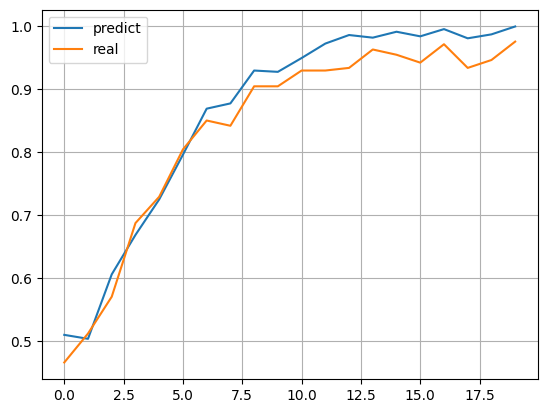

In [344]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Stride

#### stride=3

In [345]:
class ModelNN_s3(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        torch.nn.Conv2d(
            in_channels=3, out_channels=6, kernel_size=5, padding=2), # (batch, 6, 200, 200)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=3), # (batch, 6, 66, 66)

        torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=2), # (batch, 16, 66, 66)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=3), # (batch, 16, 22, 22)

        torch.nn.Conv2d(
            in_channels=16, out_channels=16, kernel_size=5, padding=0), # (batch, 16, 18, 18)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=2, stride=3), # (batch, 16, 6, 6)

        nn.Flatten(),

        torch.nn.Linear(6 * 6 * 16, 120),
        torch.nn.ReLU(),
        torch.nn.Linear(120, 84),
        torch.nn.ReLU(),
        torch.nn.Linear(84, len(classes))
    )

  def forward(self, x):
    return self.layers(x)

In [346]:
model = ModelNN_s3()
model = model.to(device)
sum(p.numel() for p in model.parameters())

88947

In [347]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [348]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.465, acc_val=0.421


Epoch [2/20] | acc_train=0.472, acc_val=0.442


Epoch [3/20] | acc_train=0.537, acc_val=0.533


Epoch [4/20] | acc_train=0.585, acc_val=0.546


Epoch [5/20] | acc_train=0.607, acc_val=0.596


...

Epoch [16/20] | acc_train=0.947, acc_val=0.900


Epoch [17/20] | acc_train=0.948, acc_val=0.900


Epoch [18/20] | acc_train=0.952, acc_val=0.917


Epoch [19/20] | acc_train=0.948, acc_val=0.908


Epoch [20/20] | acc_train=0.970, acc_val=0.925


0.9333333333333333


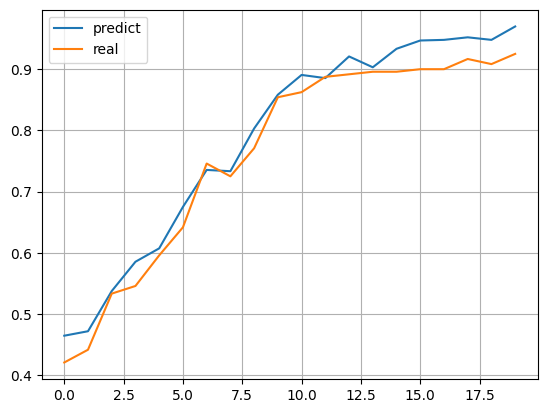

In [349]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### stride=3-3

In [350]:
class ModelNN_s3_3(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        torch.nn.Conv2d(
            in_channels=3, out_channels=6, kernel_size=5, padding=2), # (batch, 6, 200, 200)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=3, stride=3), # (batch, 6, 66, 66)

        torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=2), # (batch, 16, 66, 66)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=3, stride=3), # (batch, 16, 22, 22)

        torch.nn.Conv2d(
            in_channels=16, out_channels=16, kernel_size=5, padding=0), # (batch, 16, 18, 18)
        torch.nn.ReLU(),
        torch.nn.AvgPool2d(kernel_size=3, stride=3), # (batch, 16, 6, 6)

        nn.Flatten(),

        torch.nn.Linear(6 * 6 * 16, 120),
        torch.nn.ReLU(),
        torch.nn.Linear(120, 84),
        torch.nn.ReLU(),
        torch.nn.Linear(84, len(classes))
    )

  def forward(self, x):
    return self.layers(x)

In [351]:
model = ModelNN_s3_3()
model = model.to(device)
sum(p.numel() for p in model.parameters())

88947

In [352]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [353]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.521, acc_val=0.500


Epoch [2/20] | acc_train=0.498, acc_val=0.454


Epoch [3/20] | acc_train=0.524, acc_val=0.517


Epoch [4/20] | acc_train=0.570, acc_val=0.517


Epoch [5/20] | acc_train=0.608, acc_val=0.621


...

Epoch [16/20] | acc_train=0.905, acc_val=0.863


Epoch [17/20] | acc_train=0.912, acc_val=0.883


Epoch [18/20] | acc_train=0.922, acc_val=0.887


Epoch [19/20] | acc_train=0.926, acc_val=0.900


Epoch [20/20] | acc_train=0.927, acc_val=0.900


0.89


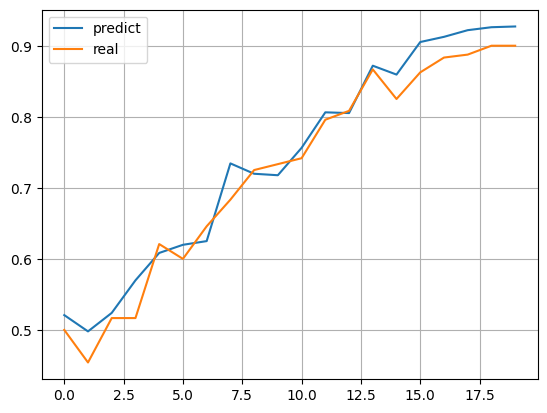

In [354]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Функция пуллинга

#### AdaptiveMaxPool2d

In [355]:
class ModelNN_ad_maxpool(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        torch.nn.Conv2d(
            in_channels=3, out_channels=6, kernel_size=5, padding=2), # (batch, 6, 200, 200)
        torch.nn.ReLU(),
        torch.nn.AdaptiveMaxPool2d((150, 150)), # (batch, 6, 150, 150)

        torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=2), # (batch, 16, 100, 100)
        torch.nn.ReLU(),
        torch.nn.AdaptiveMaxPool2d((50, 50)), # (batch, 16, 50, 50)

        torch.nn.Conv2d(
            in_channels=16, out_channels=16, kernel_size=5, padding=0), # (batch, 16, 46, 46)
        torch.nn.ReLU(),
        torch.nn.AdaptiveMaxPool2d((15, 15)), # (batch, 16, 23, 23)

        nn.Flatten(),

        torch.nn.Linear(15 * 15 * 16, 120),
        torch.nn.ReLU(),
        torch.nn.Linear(120, 84),
        torch.nn.ReLU(),
        torch.nn.Linear(84, len(classes))
    )

  def forward(self, x):
    return self.layers(x)

In [356]:
model = ModelNN_ad_maxpool()
model = model.to(device)
sum(p.numel() for p in model.parameters())

451827

In [357]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [358]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.518, acc_val=0.492


Epoch [2/20] | acc_train=0.517, acc_val=0.475


Epoch [3/20] | acc_train=0.548, acc_val=0.546


Epoch [4/20] | acc_train=0.616, acc_val=0.592


Epoch [5/20] | acc_train=0.690, acc_val=0.637


...

Epoch [16/20] | acc_train=0.990, acc_val=0.975


Epoch [17/20] | acc_train=0.982, acc_val=0.971


Epoch [18/20] | acc_train=0.982, acc_val=0.950


Epoch [19/20] | acc_train=0.988, acc_val=0.954


Epoch [20/20] | acc_train=0.996, acc_val=0.979


0.97


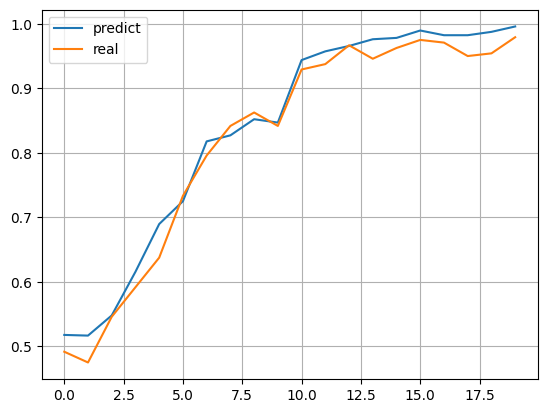

In [359]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### MaxPool2d

In [360]:
class ModelNN_maxpool(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        torch.nn.Conv2d(
            in_channels=3, out_channels=6, kernel_size=5, padding=2), # (batch, 6, 200, 200)
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2), # (batch, 6, 100, 100)

        torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=2), # (batch, 16, 100, 100)
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2), # (batch, 16, 50, 50)

        torch.nn.Conv2d(
            in_channels=16, out_channels=16, kernel_size=5, padding=0), # (batch, 16, 46, 46)
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(kernel_size=2, stride=2), # (batch, 16, 23, 23)

        nn.Flatten(),

        torch.nn.Linear(23 * 23 * 16, 120),
        torch.nn.ReLU(),
        torch.nn.Linear(120, 84),
        torch.nn.ReLU(),
        torch.nn.Linear(84, len(classes))
    )

  def forward(self, x):
    return self.layers(x)

In [361]:
model = ModelNN_maxpool()
model = model.to(device)
sum(p.numel() for p in model.parameters())

1035507

In [362]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [363]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.502, acc_val=0.454


Epoch [2/20] | acc_train=0.533, acc_val=0.525


Epoch [3/20] | acc_train=0.615, acc_val=0.583


Epoch [4/20] | acc_train=0.667, acc_val=0.629


Epoch [5/20] | acc_train=0.762, acc_val=0.767


...

Epoch [16/20] | acc_train=0.994, acc_val=0.963


Epoch [17/20] | acc_train=1.000, acc_val=0.971


Epoch [18/20] | acc_train=0.998, acc_val=0.967


Epoch [19/20] | acc_train=1.000, acc_val=0.979


Epoch [20/20] | acc_train=0.997, acc_val=0.971


0.9666666666666667


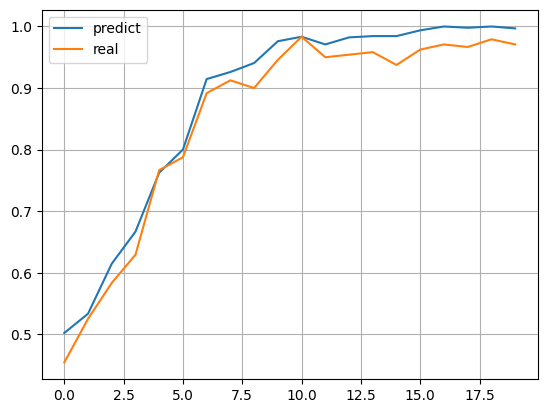

In [364]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Оптимизатор

#### RMSprop

In [365]:
model = ModelNN()
model = model.to(device)
sum(p.numel() for p in model.parameters())

1035507

In [366]:
optimizer = optim.RMSprop(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [367]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.336, acc_val=0.321


Epoch [2/20] | acc_train=0.335, acc_val=0.346


Epoch [3/20] | acc_train=0.529, acc_val=0.487


Epoch [4/20] | acc_train=0.535, acc_val=0.546


Epoch [5/20] | acc_train=0.576, acc_val=0.542


...

Epoch [16/20] | acc_train=0.895, acc_val=0.867


Epoch [17/20] | acc_train=0.820, acc_val=0.779


Epoch [18/20] | acc_train=0.929, acc_val=0.887


Epoch [19/20] | acc_train=0.948, acc_val=0.900


Epoch [20/20] | acc_train=0.909, acc_val=0.883


0.8633333333333333


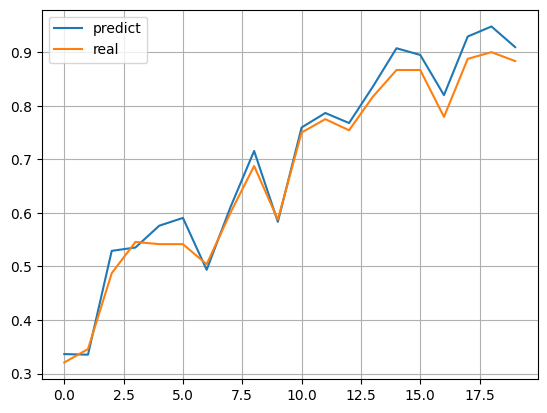

In [368]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### SGD

In [369]:
model = ModelNN()
model = model.to(device)
sum(p.numel() for p in model.parameters())

1035507

In [370]:
optimizer = optim.SGD(params=model.parameters(), lr=0.001, momentum=0.9)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [371]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.336, acc_val=0.321


Epoch [2/20] | acc_train=0.336, acc_val=0.321


Epoch [3/20] | acc_train=0.336, acc_val=0.321


Epoch [4/20] | acc_train=0.336, acc_val=0.321


Epoch [5/20] | acc_train=0.336, acc_val=0.321


...

Epoch [16/20] | acc_train=0.336, acc_val=0.321


Epoch [17/20] | acc_train=0.336, acc_val=0.321


Epoch [18/20] | acc_train=0.336, acc_val=0.321


Epoch [19/20] | acc_train=0.336, acc_val=0.321


Epoch [20/20] | acc_train=0.336, acc_val=0.321


0.3333333333333333


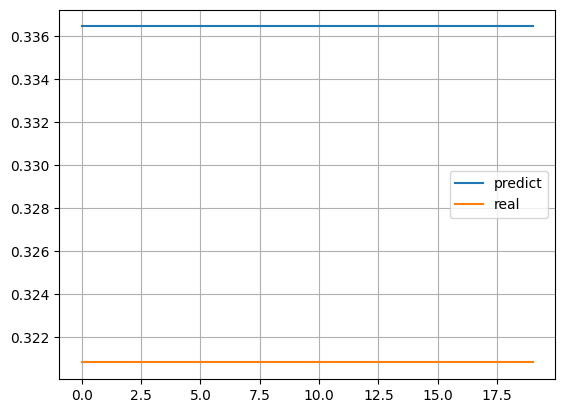

In [372]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Скорость обучения

#### lr=0.01

In [373]:
model = ModelNN()
model = model.to(device)
sum(p.numel() for p in model.parameters())

1035507

In [374]:
optimizer = optim.Adam(params=model.parameters(), lr=0.01)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [375]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.336, acc_val=0.321


Epoch [2/20] | acc_train=0.336, acc_val=0.321


Epoch [3/20] | acc_train=0.336, acc_val=0.321


Epoch [4/20] | acc_train=0.330, acc_val=0.346


Epoch [5/20] | acc_train=0.336, acc_val=0.321


...

Epoch [16/20] | acc_train=0.333, acc_val=0.333


Epoch [17/20] | acc_train=0.333, acc_val=0.333


Epoch [18/20] | acc_train=0.336, acc_val=0.321


Epoch [19/20] | acc_train=0.336, acc_val=0.321


Epoch [20/20] | acc_train=0.336, acc_val=0.321


0.3333333333333333


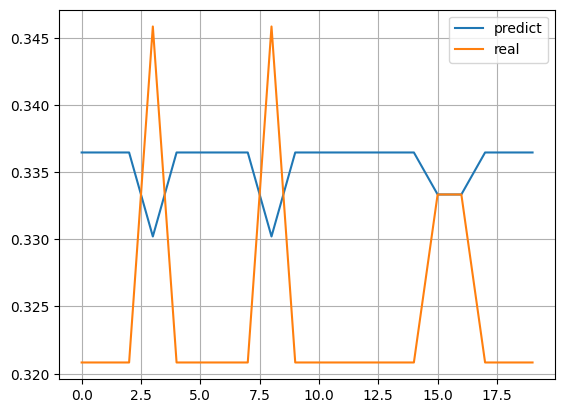

In [376]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### lr=0.005

In [377]:
model = ModelNN()
model = model.to(device)
sum(p.numel() for p in model.parameters())

1035507

In [378]:
optimizer = optim.Adam(params=model.parameters(), lr=0.005)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [379]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.330, acc_val=0.346


Epoch [2/20] | acc_train=0.330, acc_val=0.346


Epoch [3/20] | acc_train=0.336, acc_val=0.321


Epoch [4/20] | acc_train=0.336, acc_val=0.321


Epoch [5/20] | acc_train=0.333, acc_val=0.333


...

Epoch [16/20] | acc_train=0.333, acc_val=0.333


Epoch [17/20] | acc_train=0.336, acc_val=0.321


Epoch [18/20] | acc_train=0.336, acc_val=0.321


Epoch [19/20] | acc_train=0.333, acc_val=0.333


Epoch [20/20] | acc_train=0.333, acc_val=0.333


0.3333333333333333


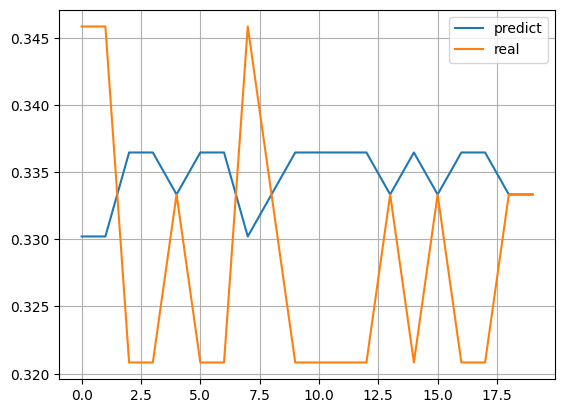

In [380]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Размер батча

#### batch_size = 150

In [381]:
model = ModelNN()
model = model.to(device)
sum(p.numel() for p in model.parameters())

1035507

In [382]:
transforms = tfs.Compose(
    [
        tfs.ToImage(),
        tfs.ToDtype(torch.float32, scale=True)
    ]
)

train_size = 0.8
batch_size = 150
album = False

In [383]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [384]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [385]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.346, acc_val=0.283


Epoch [2/20] | acc_train=0.520, acc_val=0.458


Epoch [3/20] | acc_train=0.531, acc_val=0.471


Epoch [4/20] | acc_train=0.556, acc_val=0.512


Epoch [5/20] | acc_train=0.622, acc_val=0.583


...

Epoch [16/20] | acc_train=0.957, acc_val=0.892


Epoch [17/20] | acc_train=0.968, acc_val=0.908


Epoch [18/20] | acc_train=0.945, acc_val=0.900


Epoch [19/20] | acc_train=0.984, acc_val=0.942


Epoch [20/20] | acc_train=0.978, acc_val=0.908


0.93


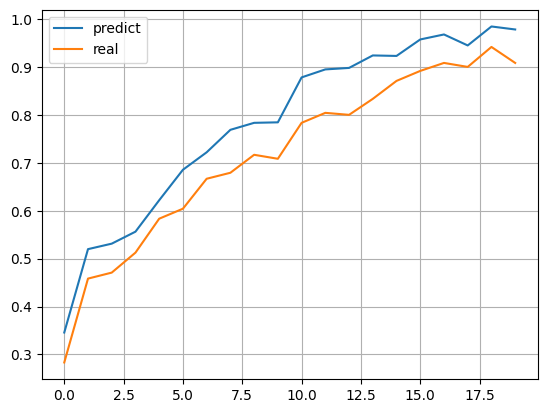

In [386]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### batch_size = 50

In [387]:
model = ModelNN()
model = model.to(device)
sum(p.numel() for p in model.parameters())

1035507

In [388]:
transforms = tfs.Compose(
    [
        tfs.ToImage(),
        tfs.ToDtype(torch.float32, scale=True)
    ]
)

train_size = 0.8
batch_size = 50
album = False

In [389]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [390]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 20

In [391]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/20] | acc_train=0.569, acc_val=0.521


Epoch [2/20] | acc_train=0.548, acc_val=0.487


Epoch [3/20] | acc_train=0.630, acc_val=0.596


Epoch [4/20] | acc_train=0.761, acc_val=0.717


Epoch [5/20] | acc_train=0.825, acc_val=0.787


...

Epoch [16/20] | acc_train=0.998, acc_val=0.946


Epoch [17/20] | acc_train=0.992, acc_val=0.942


Epoch [18/20] | acc_train=0.975, acc_val=0.908


Epoch [19/20] | acc_train=0.999, acc_val=0.946


Epoch [20/20] | acc_train=0.982, acc_val=0.929


0.9266666666666666


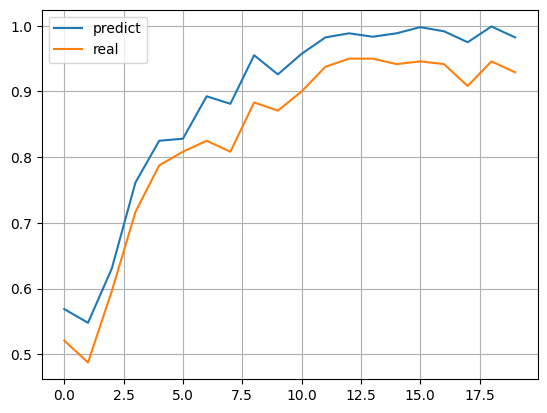

In [392]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Число эпох

#### epochs = 30

In [393]:
model = ModelNN()
model = model.to(device)
sum(p.numel() for p in model.parameters())

1035507

In [394]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [395]:
transforms = tfs.Compose(
    [
        tfs.ToImage(),
        tfs.ToDtype(torch.float32, scale=True)
    ]
)

train_size = 0.8
batch_size = 100
album = False

In [396]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [397]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/30] | acc_train=0.478, acc_val=0.412


Epoch [2/30] | acc_train=0.522, acc_val=0.446


Epoch [3/30] | acc_train=0.621, acc_val=0.562


Epoch [4/30] | acc_train=0.719, acc_val=0.646


Epoch [5/30] | acc_train=0.744, acc_val=0.658


...

Epoch [26/30] | acc_train=1.000, acc_val=0.954


Epoch [27/30] | acc_train=1.000, acc_val=0.950


Epoch [28/30] | acc_train=1.000, acc_val=0.954


Epoch [29/30] | acc_train=1.000, acc_val=0.950


Epoch [30/30] | acc_train=1.000, acc_val=0.958


0.9666666666666667


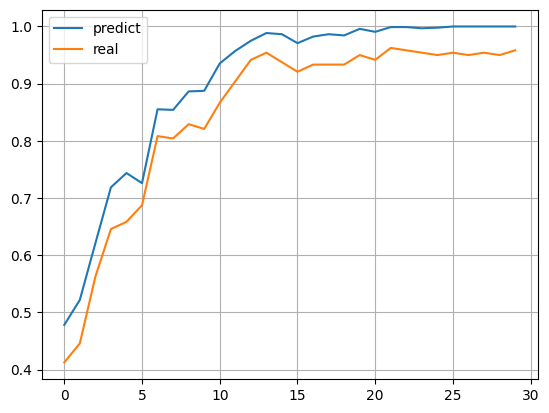

In [398]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Модель, с учетом экспериментов

#### Новая модель

In [399]:
class ModelNN_v2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      torch.nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2), # (batch, 6, 200, 200)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=3),                              # (batch, 6, 66, 66)

      torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=2), # (batch, 16, 66, 66)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=3),                               # (batch, 16, 22, 22)

      torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=5, padding=2), # (batch, 16, 22, 22)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=2),                                # (batch, 16, 7, 7)

      # Новый сверточный слой 1
      torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1), # (batch, 32, 7, 7)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=1),                                # (batch, 32, 11, 11)

      # Новый сверточный слой 2
      torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # (batch, 64, 11, 11)
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=1),                                # (batch, 64, 5, 5)

      nn.Flatten(),

      torch.nn.Linear(6 * 6 * 64, 120),
      torch.nn.ReLU(),
      torch.nn.Linear(120, 84),
      torch.nn.ReLU(),
      torch.nn.Linear(84, len(classes))
    )

  def forward(self, x):
    return self.layers(x)


In [400]:
model = ModelNN_v2()
model = model.to(device)
sum(p.numel() for p in model.parameters())

319443

In [401]:
transforms = tfs.Compose(
    [
        tfs.ToImage(),
        tfs.ToDtype(torch.float32, scale=True)
    ]
)

train_size = 0.8
batch_size = 100
album = False

In [402]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [403]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [404]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/30] | acc_train=0.327, acc_val=0.358


Epoch [2/30] | acc_train=0.344, acc_val=0.292


Epoch [3/30] | acc_train=0.448, acc_val=0.417


Epoch [4/30] | acc_train=0.498, acc_val=0.487


Epoch [5/30] | acc_train=0.508, acc_val=0.492


...

Epoch [26/30] | acc_train=0.941, acc_val=0.921


Epoch [27/30] | acc_train=0.966, acc_val=0.942


Epoch [28/30] | acc_train=0.973, acc_val=0.950


Epoch [29/30] | acc_train=0.973, acc_val=0.946


Epoch [30/30] | acc_train=0.960, acc_val=0.938


0.9633333333333334


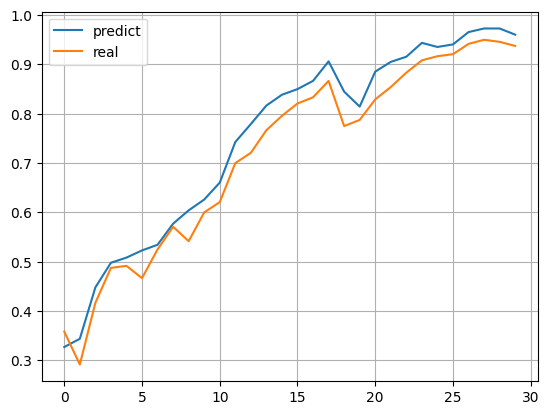

In [405]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### Модель с большим кол-вом сверточных слоев (в сравнении)

In [406]:
model = ModelNN_cnn5()
model = model.to(device)
sum(p.numel() for p in model.parameters())

234963

In [407]:
transforms = tfs.Compose(
    [
        tfs.ToImage(),
        tfs.ToDtype(torch.float32, scale=True)
    ]
)

train_size = 0.8
batch_size = 100
album = False

In [408]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [409]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [410]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/30] | acc_train=0.323, acc_val=0.375


Epoch [2/30] | acc_train=0.485, acc_val=0.446


Epoch [3/30] | acc_train=0.550, acc_val=0.604


Epoch [4/30] | acc_train=0.584, acc_val=0.658


Epoch [5/30] | acc_train=0.664, acc_val=0.683


...

Epoch [26/30] | acc_train=0.999, acc_val=0.975


Epoch [27/30] | acc_train=0.996, acc_val=0.988


Epoch [28/30] | acc_train=0.995, acc_val=0.983


Epoch [29/30] | acc_train=0.986, acc_val=0.950


Epoch [30/30] | acc_train=0.991, acc_val=0.963


0.9666666666666667


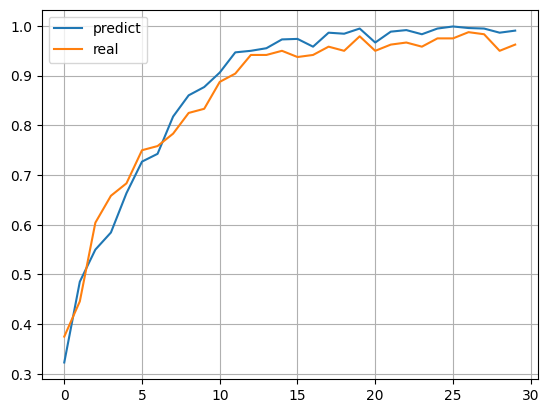

In [411]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

## Предотвращение переобучения

### Пример переобучения

In [557]:
class ModelNN_mini(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      torch.nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2),  
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=3),  

      torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=2), 
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=3),  

      nn.Flatten(),

      torch.nn.Linear(22 * 22 * 16, 256),
      torch.nn.ReLU(),

      torch.nn.Linear(256, 128),
      torch.nn.ReLU(),
      torch.nn.Linear(128, 90),
      torch.nn.ReLU(),

      torch.nn.Linear(90, 84),
      torch.nn.ReLU(),

      torch.nn.Linear(84, 50),
      torch.nn.ReLU(),

      torch.nn.Linear(50, len(classes))
    )

  def forward(self, x):
    return self.layers(x)


In [558]:
model = ModelNN_mini()
model = model.to(device)
sum(p.numel() for p in model.parameters())

2042145

In [559]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [560]:
transforms = tfs.Compose(
    [
        tfs.ToImage(),
        tfs.ToDtype(torch.float32, scale=True)
    ]
)

train_size = 0.8
batch_size = 100
album = False

In [561]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [562]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/30] | acc_train=0.394, acc_val=0.333


Epoch [2/30] | acc_train=0.459, acc_val=0.442


Epoch [3/30] | acc_train=0.490, acc_val=0.463


Epoch [4/30] | acc_train=0.561, acc_val=0.546


Epoch [5/30] | acc_train=0.596, acc_val=0.575


...

Epoch [26/30] | acc_train=0.984, acc_val=0.912


Epoch [27/30] | acc_train=0.988, acc_val=0.917


Epoch [28/30] | acc_train=0.995, acc_val=0.929


Epoch [29/30] | acc_train=0.994, acc_val=0.929


Epoch [30/30] | acc_train=0.997, acc_val=0.917


0.95


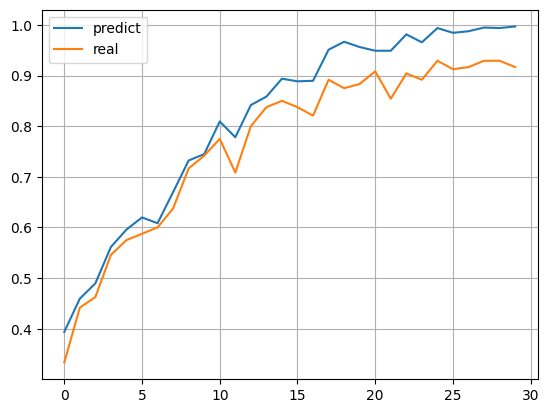

In [563]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Dropout

#### nn.Dropout2d(0.3)

In [453]:
class ModelNN_mini_drop3(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      torch.nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2),  
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=3),  
      nn.Dropout2d(0.3),

      torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=2), 
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=3),  
      nn.Dropout2d(0.3),

      nn.Flatten(),

      torch.nn.Linear(22 * 22 * 16, 256),
      torch.nn.ReLU(),
      nn.Dropout1d(0.3),

      torch.nn.Linear(256, 128),
      torch.nn.ReLU(),
      nn.Dropout1d(0.3),
      torch.nn.Linear(128, 90),
      torch.nn.ReLU(),
      nn.Dropout1d(0.3),

      torch.nn.Linear(90, 84),
      torch.nn.ReLU(),
      nn.Dropout1d(0.3),

      torch.nn.Linear(84, 50),
      torch.nn.ReLU(),
      nn.Dropout1d(0.3),

      torch.nn.Linear(50, len(classes))
    )

  def forward(self, x):
    return self.layers(x)


In [454]:
model = ModelNN_mini_drop3()
model = model.to(device)
sum(p.numel() for p in model.parameters())

2042145

In [455]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [456]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/30] | acc_train=0.334, acc_val=0.329


Epoch [2/30] | acc_train=0.334, acc_val=0.329


Epoch [3/30] | acc_train=0.334, acc_val=0.329


Epoch [4/30] | acc_train=0.334, acc_val=0.329


Epoch [5/30] | acc_train=0.334, acc_val=0.329


...

Epoch [26/30] | acc_train=0.475, acc_val=0.475


Epoch [27/30] | acc_train=0.340, acc_val=0.342


Epoch [28/30] | acc_train=0.384, acc_val=0.392


Epoch [29/30] | acc_train=0.335, acc_val=0.325


Epoch [30/30] | acc_train=0.297, acc_val=0.267


0.2966666666666667


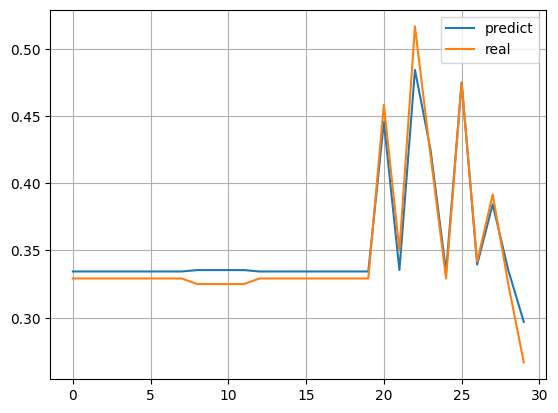

In [457]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### nn.Dropout2d(0.15)

In [458]:
class ModelNN_mini_drop15(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      torch.nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2),  
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=3),  
      nn.Dropout2d(0.15),

      torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=2), 
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=3),  
      nn.Dropout2d(0.15),

      nn.Flatten(),

      torch.nn.Linear(22 * 22 * 16, 256),
      torch.nn.ReLU(),
      nn.Dropout1d(0.15),

      torch.nn.Linear(256, 128),
      torch.nn.ReLU(),
      nn.Dropout1d(0.15),
      torch.nn.Linear(128, 90),
      torch.nn.ReLU(),
      nn.Dropout1d(0.15),

      torch.nn.Linear(90, 84),
      torch.nn.ReLU(),
      nn.Dropout1d(0.15),

      torch.nn.Linear(84, 50),
      torch.nn.ReLU(),
      nn.Dropout1d(0.15),

      torch.nn.Linear(50, len(classes))
    )

  def forward(self, x):
    return self.layers(x)


In [459]:
model = ModelNN_mini_drop15()
model = model.to(device)
sum(p.numel() for p in model.parameters())

2042145

In [460]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [461]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/30] | acc_train=0.339, acc_val=0.333


Epoch [2/30] | acc_train=0.335, acc_val=0.325


Epoch [3/30] | acc_train=0.459, acc_val=0.446


Epoch [4/30] | acc_train=0.466, acc_val=0.442


Epoch [5/30] | acc_train=0.467, acc_val=0.450


...

Epoch [26/30] | acc_train=0.895, acc_val=0.867


Epoch [27/30] | acc_train=0.936, acc_val=0.879


Epoch [28/30] | acc_train=0.929, acc_val=0.883


Epoch [29/30] | acc_train=0.939, acc_val=0.904


Epoch [30/30] | acc_train=0.909, acc_val=0.896


0.8666666666666667


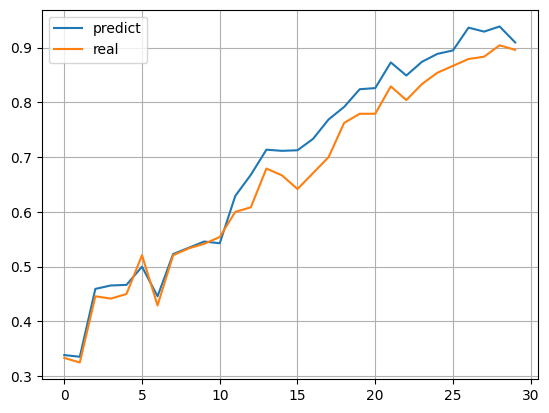

In [462]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### BatchNorm

In [466]:
class ModelNN_mini_bn(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      torch.nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2),  
      nn.BatchNorm2d(6),
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=3),  

      torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=2), 
      nn.BatchNorm2d(16),
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=3),  

      nn.Flatten(),

      torch.nn.Linear(22 * 22 * 16, 256),
      nn.BatchNorm1d(256),
      torch.nn.ReLU(),

      torch.nn.Linear(256, 128),
      nn.BatchNorm1d(128),
      torch.nn.ReLU(),
      torch.nn.Linear(128, 90),
      nn.BatchNorm1d(90),
      torch.nn.ReLU(),

      torch.nn.Linear(90, 84),
      nn.BatchNorm1d(84),
      torch.nn.ReLU(),

      torch.nn.Linear(84, 50),
      nn.BatchNorm1d(50),
      torch.nn.ReLU(),

      torch.nn.Linear(50, len(classes))
    )

  def forward(self, x):
    return self.layers(x)


In [467]:
model = ModelNN_mini_bn()
model = model.to(device)
sum(p.numel() for p in model.parameters())

2043405

In [468]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [469]:
model, res_lst, res_lst_val = train_model(model, device, train_data, train_data_val, 
                                            optimizer, loss_func, epochs)

Epoch [1/30] | acc_train=0.334, acc_val=0.329


Epoch [2/30] | acc_train=0.334, acc_val=0.329


Epoch [3/30] | acc_train=0.389, acc_val=0.388


Epoch [4/30] | acc_train=0.451, acc_val=0.433


Epoch [5/30] | acc_train=0.552, acc_val=0.562


...

Epoch [26/30] | acc_train=0.954, acc_val=0.854


Epoch [27/30] | acc_train=1.000, acc_val=0.958


Epoch [28/30] | acc_train=0.998, acc_val=0.933


Epoch [29/30] | acc_train=0.997, acc_val=0.946


Epoch [30/30] | acc_train=1.000, acc_val=0.967


0.9666666666666667


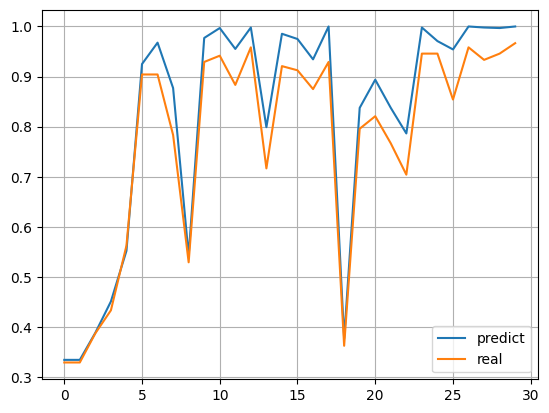

In [470]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Callbacks

#### Начальные функции и классы

In [501]:
from tqdm import tqdm
import torch

class ModelCheckpoint:
    def __init__(self, filepath, save_best_only=True, save_step=1, metric='accuracy'):
        self.filepath = filepath
        self.save_best_only = save_best_only
        self.save_step = save_step
        self.metric=metric

        if self.metric == 'accuracy':
            self.best = -float('inf')
            self.compare = lambda a, b: a > b
        elif self.metric == 'loss':
            self.best = float('inf')
            self.compare = lambda a, b: a < b

    def step(self, model, cur_metric_value, epoch):
        save_flag = False

        # Сохраняем по расписанию
        if self.save_step > 0 and (epoch + 1) % self.save_step == 0:
            # Сохраняем при улучшении метрики
            if self.save_best_only:
                if self.compare(cur_metric_value, self.best):
                    self.best = cur_metric_value
                    save_flag = True
            else:
                save_flag = True

        if save_flag:
            torch.save(model.state_dict(), 
                       self.filepath.format(epoch=epoch + 1, metric=self.metric, metric_val=cur_metric_value))
            print(f"ModelCheckpoint: model saved")

In [502]:
class EarlyStopping:
    def __init__(self, patience=5, save_best=True, filepath=None, metric='accuracy'):
        self.patience = patience
        self.save_best = save_best
        self.filepath = filepath
        self.metric=metric

        self.counter = 0
        self.best_val = None
        self.best_model = None
        self.early_stop = False

        if self.metric == 'accuracy':
            self.best_val = -float('inf')
            self.compare = lambda a, b: a > b
        elif self.metric == 'loss':
            self.best_val = float('inf')
            self.compare = lambda a, b: a < b

    def step(self, model, cur_metric_value, epoch):
        if self.compare(cur_metric_value, self.best_val):
            self.best_val = cur_metric_value
            self.best_model = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            print(f"EarlyStopping: no improvement for {self.counter} epochs")

        if self.counter >= self.patience:
            self.early_stop = True
            if self.save_best:
                torch.save(self.best_model, 
                        self.filepath.format(metric=self.metric, metric_val=self.best_val))
            else:
                torch.save(model.state_dict(), 
                        self.filepath.format(metric=self.metric, metric_val=cur_metric_value))
            print(f"EarlyStopping: stopping training at epoch {epoch + 1}")

In [503]:
def update_scheduler(lr_scheduler, val_res):
    if lr_scheduler is not None:
        if isinstance(lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            lr_scheduler.step(val_res)
        else:
            lr_scheduler.step()

def do_callbacks(model, callbacks, epoch, val_res):
    for cb in callbacks:
        # фиксируем чекпоинты
        if isinstance(cb, ModelCheckpoint):
            cb.step(model, val_res, epoch)

        # проверяем на улучшение
        elif isinstance(cb, EarlyStopping):
            cb.step(model, val_res, epoch)

            if cb.early_stop:
                if cb.save_best == True:
                    model.load_state_dict(cb.best_model)
                return True
    return False

def train_model_with_callbacks(
    model, device, 
    train_data, train_size, train_data_val,
    optimizer, loss_func, epochs,
    metric='accuracy',
    callbacks=[], lr_scheduler=None
):
    model.to(device)
    res_lst_val = []
    res_lst = []

    for epoch in range(epochs):
        model.train()
        loss_mean = 0
        lm_count = 0
        train_tqdm = tqdm(train_data, leave=False)

        for x_train, y_train in train_tqdm:
            x_train = x_train.to(device)
            y_train = y_train.to(device)

            predict = model(x_train)
            loss = loss_func(predict, y_train)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            lm_count += 1
            loss_mean = loss.item() / lm_count + loss_mean * (1 - 1 / lm_count)
            train_tqdm.set_description(f"Epoch [{epoch+1}/{epochs}], loss: {loss_mean:.4f}")

        # метрики на обучении и валидации
        if metric == 'accuracy':
            train_res = accuracy_model(model, device, train_data)
            val_res = accuracy_model(model, device, train_data_val)
        elif metric == 'loss':
            train_res = loss_mean
            val_res = loss_model(model, loss_func, train_data_val)

        res_lst.append(train_res)
        res_lst_val.append(val_res)

        print(f'Epoch [{epoch+1}/{epochs}] | {metric}_train={train_res:.3f}, {metric}_val={val_res:.3f}')

        # callbacks
        early_stop = do_callbacks(model, callbacks, epoch, val_res)
        if early_stop:
            return model, res_lst, res_lst_val
        
        # scheduler
        update_scheduler(lr_scheduler, val_res)

    return model, res_lst, res_lst_val


#### Пример реализации

In [479]:
model = ModelNN_mini_bn()
model = model.to(device)
sum(p.numel() for p in model.parameters())

2043405

In [480]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [481]:
transforms = tfs.Compose(
    [
        tfs.ToImage(),
        tfs.ToDtype(torch.float32, scale=True)
    ]
)

train_size = 0.8
batch_size = 100
album = False

In [482]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [483]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'loss'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=1, 
    save_best=True,
    metric=metric
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

model, res_lst, res_lst_val = train_model_with_callbacks(
    model, device, train_data, train_size, train_data_val,
    optimizer, loss_func, epochs=50,
    metric=metric,
    callbacks=[earlystop_cb],
    lr_scheduler=scheduler
)


Epoch [1/50] | loss_train=0.919, loss_val=1.094


Epoch [2/50] | loss_train=0.605, loss_val=1.035


Epoch [3/50] | loss_train=0.439, loss_val=0.909


Epoch [4/50] | loss_train=0.324, loss_val=0.540


Epoch [5/50] | loss_train=0.206, loss_val=0.451


Epoch [6/50] | loss_train=0.149, loss_val=0.696
EarlyStopping: no improvement for 1 epochs
EarlyStopping: stopping training at epoch 6


0.8266666666666667


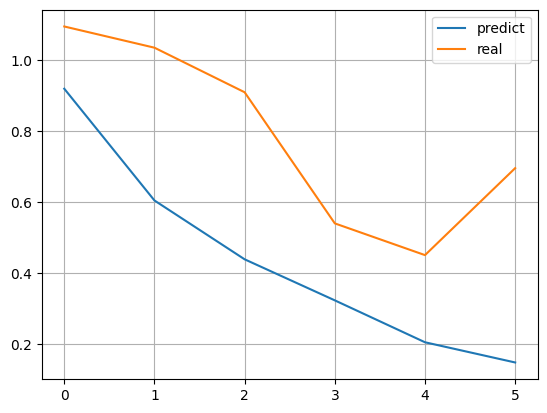

In [485]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### patience=1

In [504]:
model = ModelNN_mini_bn()
model = model.to(device)
sum(p.numel() for p in model.parameters())

2043405

In [505]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [506]:
transforms = tfs.Compose(
    [
        tfs.ToImage(),
        tfs.ToDtype(torch.float32, scale=True)
    ]
)

train_size = 0.8
batch_size = 100
album = False

In [507]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [508]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'accuracy'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=1, 
    save_best=True,
    metric=metric
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

model, res_lst, res_lst_val = train_model_with_callbacks(
    model, device, train_data, train_size, train_data_val,
    optimizer, loss_func, epochs=50,
    metric=metric,
    callbacks=[earlystop_cb],
    lr_scheduler=scheduler
)


Epoch [1/50] | accuracy_train=0.482, accuracy_val=0.463


Epoch [2/50] | accuracy_train=0.568, accuracy_val=0.558


Epoch [3/50] | accuracy_train=0.607, accuracy_val=0.571


Epoch [4/50] | accuracy_train=0.860, accuracy_val=0.829


Epoch [5/50] | accuracy_train=0.863, accuracy_val=0.858


Epoch [6/50] | accuracy_train=0.766, accuracy_val=0.738
EarlyStopping: no improvement for 1 epochs
EarlyStopping: stopping training at epoch 6


0.8166666666666667


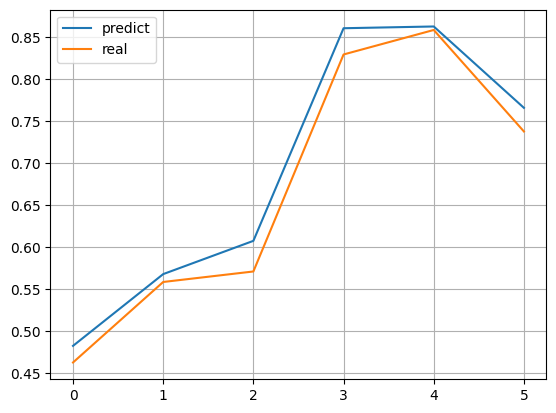

In [509]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### patience=5

In [510]:
model = ModelNN_mini_bn()
model = model.to(device)
sum(p.numel() for p in model.parameters())

2043405

In [511]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [512]:
transforms = tfs.Compose(
    [
        tfs.ToImage(),
        tfs.ToDtype(torch.float32, scale=True)
    ]
)

train_size = 0.8
batch_size = 100
album = False

In [513]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [514]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'accuracy'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=5, 
    save_best=True,
    metric=metric
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

model, res_lst, res_lst_val = train_model_with_callbacks(
    model, device, train_data, train_size, train_data_val,
    optimizer, loss_func, epochs=50,
    metric=metric,
    callbacks=[earlystop_cb],
    lr_scheduler=scheduler
)


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch [1/50] | accuracy_train=0.325, accuracy_val=0.367


Epoch [2/50] | accuracy_train=0.364, accuracy_val=0.375


Epoch [3/50] | accuracy_train=0.525, accuracy_val=0.579


Epoch [4/50] | accuracy_train=0.613, accuracy_val=0.642


...

Epoch [22/50] | accuracy_train=1.000, accuracy_val=0.967
EarlyStopping: no improvement for 1 epochs


Epoch [23/50] | accuracy_train=1.000, accuracy_val=0.963
EarlyStopping: no improvement for 2 epochs


Epoch [24/50] | accuracy_train=1.000, accuracy_val=0.958
EarlyStopping: no improvement for 3 epochs


Epoch [25/50] | accuracy_train=1.000, accuracy_val=0.958
EarlyStopping: no improvement for 4 epochs


Epoch [26/50] | accuracy_train=1.000, accuracy_val=0.958
EarlyStopping: no improvement for 5 epochs
EarlyStopping: stopping training at epoch 26


0.9533333333333334


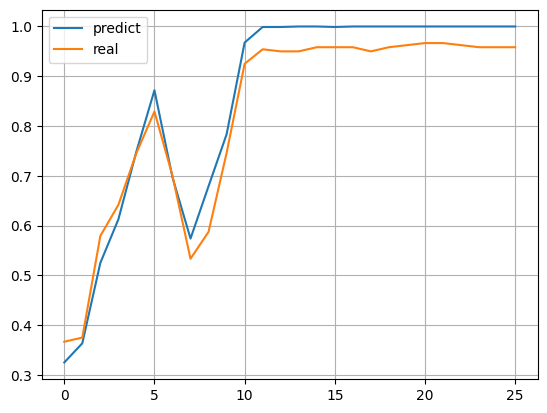

In [515]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### patience=10

In [516]:
model = ModelNN_mini_bn()
model = model.to(device)
sum(p.numel() for p in model.parameters())

2043405

In [517]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [518]:
transforms = tfs.Compose(
    [
        tfs.ToImage(),
        tfs.ToDtype(torch.float32, scale=True)
    ]
)

train_size = 0.8
batch_size = 100
album = False

In [519]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [520]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'accuracy'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=10, 
    save_best=True,
    metric=metric
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

model, res_lst, res_lst_val = train_model_with_callbacks(
    model, device, train_data, train_size, train_data_val,
    optimizer, loss_func, epochs=50,
    metric=metric,
    callbacks=[earlystop_cb],
    lr_scheduler=scheduler
)


Epoch [1/50] | accuracy_train=0.405, accuracy_val=0.338


Epoch [2/50] | accuracy_train=0.392, accuracy_val=0.358


Epoch [3/50] | accuracy_train=0.557, accuracy_val=0.592


Epoch [4/50] | accuracy_train=0.624, accuracy_val=0.608


Epoch [5/50] | accuracy_train=0.646, accuracy_val=0.671


...

Epoch [28/50] | accuracy_train=1.000, accuracy_val=0.963
EarlyStopping: no improvement for 6 epochs


Epoch [29/50] | accuracy_train=1.000, accuracy_val=0.963
EarlyStopping: no improvement for 7 epochs


Epoch [30/50] | accuracy_train=1.000, accuracy_val=0.963
EarlyStopping: no improvement for 8 epochs


Epoch [31/50] | accuracy_train=1.000, accuracy_val=0.963
EarlyStopping: no improvement for 9 epochs


Epoch [32/50] | accuracy_train=1.000, accuracy_val=0.963
EarlyStopping: no improvement for 10 epochs
EarlyStopping: stopping training at epoch 32


0.9566666666666667


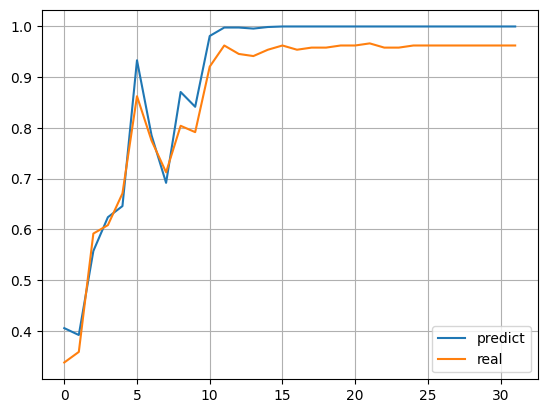

In [521]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Аугментация

#### Базовые функции

In [564]:
class AlbumentationsTransform:
    def __init__(self, albumentations_transform):
        self.albumentations_transform = albumentations_transform

    def __call__(self, img):
        img = np.array(img)
        augmented = self.albumentations_transform(image=img)
        return augmented['image']

In [565]:
class ModelNN_mini_bn(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      torch.nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2),  
      nn.BatchNorm2d(6),
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=3),  

      torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=2), 
      nn.BatchNorm2d(16),
      torch.nn.ReLU(),
      torch.nn.AvgPool2d(kernel_size=3, stride=3),  

      nn.Flatten(),

      torch.nn.Linear(24 * 24 * 16, 256),
      nn.BatchNorm1d(256),
      torch.nn.ReLU(),

      torch.nn.Linear(256, 128),
      nn.BatchNorm1d(128),
      torch.nn.ReLU(),
      torch.nn.Linear(128, 90),
      nn.BatchNorm1d(90),
      torch.nn.ReLU(),

      torch.nn.Linear(90, 84),
      nn.BatchNorm1d(84),
      torch.nn.ReLU(),

      torch.nn.Linear(84, 50),
      nn.BatchNorm1d(50),
      torch.nn.ReLU(),

      torch.nn.Linear(50, len(classes))
    )

  def forward(self, x):
    return self.layers(x)


#### Положение камеры

In [531]:
model = ModelNN_mini_bn()
model = model.to(device)
sum(p.numel() for p in model.parameters())

2420237

In [532]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [533]:
transforms = A.Compose(
    [
        A.Affine(
            translate_percent={"x": (-0.15, 0.15), "y": (-0.15, 0.15)},
            scale=(0.85, 1.15),
            rotate=(-15, 15),
            p=0.5),
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

train_size = 0.8
batch_size = 100
album = True

In [534]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

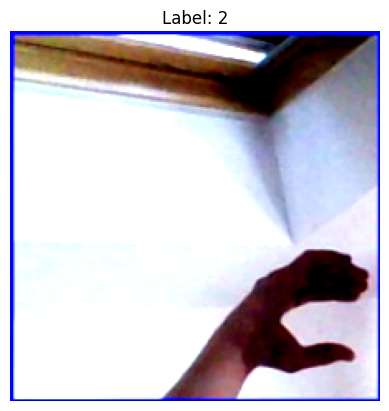

In [535]:
data_iter = iter(train_data)
images, labels = next(data_iter)

img = images[0]  # тензор [C, H, W]

img = img.permute(1, 2, 0).cpu().numpy()  # [H, W, C]
img = img * 0.5 + 0.5
img = np.clip(img, 0, 1)

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f'Label: {labels[0].item()}')
plt.axis('off')
plt.show()


In [536]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'accuracy'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=5, 
    save_best=True,
    metric=metric
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

model, res_lst, res_lst_val = train_model_with_callbacks(
    model, device, train_data, train_size, train_data_val,
    optimizer, loss_func, epochs=50,
    metric=metric,
    callbacks=[earlystop_cb],
    lr_scheduler=scheduler
)


Epoch [1/50] | accuracy_train=0.423, accuracy_val=0.471


Epoch [2/50] | accuracy_train=0.679, accuracy_val=0.662


Epoch [3/50] | accuracy_train=0.719, accuracy_val=0.708


Epoch [4/50] | accuracy_train=0.705, accuracy_val=0.704
EarlyStopping: no improvement for 1 epochs


Epoch [5/50] | accuracy_train=0.766, accuracy_val=0.733


...

Epoch [13/50] | accuracy_train=0.955, accuracy_val=0.942
EarlyStopping: no improvement for 1 epochs


Epoch [14/50] | accuracy_train=0.959, accuracy_val=0.946
EarlyStopping: no improvement for 2 epochs


Epoch [15/50] | accuracy_train=0.957, accuracy_val=0.946
EarlyStopping: no improvement for 3 epochs


Epoch [16/50] | accuracy_train=0.964, accuracy_val=0.938
EarlyStopping: no improvement for 4 epochs


Epoch [17/50] | accuracy_train=0.964, accuracy_val=0.946
EarlyStopping: no improvement for 5 epochs
EarlyStopping: stopping training at epoch 17


0.9333333333333333


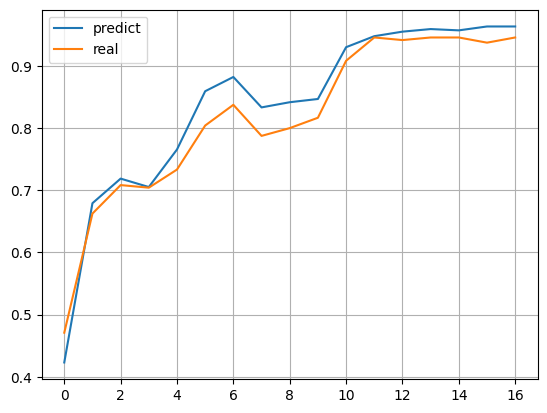

In [537]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### Яркость изображения

In [566]:
model = ModelNN_mini_bn()
model = model.to(device)
sum(p.numel() for p in model.parameters())

2420237

In [567]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [568]:
transforms = A.Compose(
    [
        A.RandomBrightnessContrast(p=0.2),
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

train_size = 0.8
batch_size = 100
album = True

In [569]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

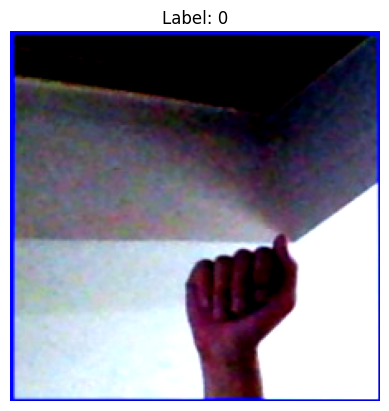

In [570]:
data_iter = iter(train_data)
images, labels = next(data_iter)

img = images[0]  # тензор [C, H, W]

img = img.permute(1, 2, 0).cpu().numpy()  # [H, W, C]
img = img * 0.5 + 0.5
img = np.clip(img, 0, 1)

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f'Label: {labels[0].item()}')
plt.axis('off')
plt.show()


In [571]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'accuracy'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=5, 
    save_best=True,
    metric=metric
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

model, res_lst, res_lst_val = train_model_with_callbacks(
    model, device, train_data, train_size, train_data_val,
    optimizer, loss_func, epochs=50,
    metric=metric,
    callbacks=[earlystop_cb],
    lr_scheduler=scheduler
)


Epoch [1/50] | accuracy_train=0.356, accuracy_val=0.346


Epoch [2/50] | accuracy_train=0.716, accuracy_val=0.654


Epoch [3/50] | accuracy_train=0.819, accuracy_val=0.783


Epoch [4/50] | accuracy_train=0.531, accuracy_val=0.504
EarlyStopping: no improvement for 1 epochs


Epoch [5/50] | accuracy_train=0.812, accuracy_val=0.762
EarlyStopping: no improvement for 2 epochs


...

Epoch [18/50] | accuracy_train=1.000, accuracy_val=0.946
EarlyStopping: no improvement for 1 epochs


Epoch [19/50] | accuracy_train=1.000, accuracy_val=0.954
EarlyStopping: no improvement for 2 epochs


Epoch [20/50] | accuracy_train=1.000, accuracy_val=0.946
EarlyStopping: no improvement for 3 epochs


Epoch [21/50] | accuracy_train=1.000, accuracy_val=0.954
EarlyStopping: no improvement for 4 epochs


Epoch [22/50] | accuracy_train=1.000, accuracy_val=0.950
EarlyStopping: no improvement for 5 epochs
EarlyStopping: stopping training at epoch 22


0.9666666666666667


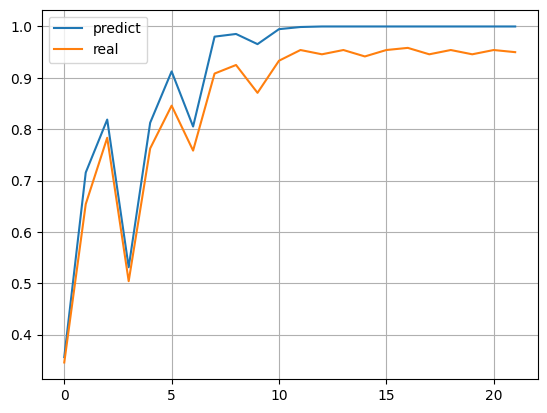

In [572]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### Искажения камеры

In [579]:
model = ModelNN_mini_bn()
model = model.to(device)
sum(p.numel() for p in model.parameters())

2420237

In [580]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [581]:
transforms = A.Compose(
    [
        A.OneOf([
            A.MotionBlur(p=0.2),
            A.OpticalDistortion(p=0.2),
            A.GaussNoise(p=0.2)
        ], p=1),
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

train_size = 0.8
batch_size = 100
album = True

In [582]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

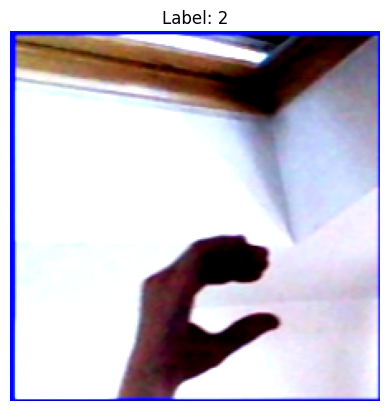

In [583]:
data_iter = iter(train_data)
images, labels = next(data_iter)

img = images[0]  # тензор [C, H, W]

img = img.permute(1, 2, 0).cpu().numpy()  # [H, W, C]
img = img * 0.5 + 0.5
img = np.clip(img, 0, 1)

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f'Label: {labels[0].item()}')
plt.axis('off')
plt.show()


In [584]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'accuracy'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=5, 
    save_best=True,
    metric=metric
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

model, res_lst, res_lst_val = train_model_with_callbacks(
    model, device, train_data, train_size, train_data_val,
    optimizer, loss_func, epochs=50,
    metric=metric,
    callbacks=[earlystop_cb],
    lr_scheduler=scheduler
)


Epoch [1/50] | accuracy_train=0.541, accuracy_val=0.508


Epoch [2/50] | accuracy_train=0.755, accuracy_val=0.692


Epoch [3/50] | accuracy_train=0.853, accuracy_val=0.804


Epoch [4/50] | accuracy_train=0.849, accuracy_val=0.783
EarlyStopping: no improvement for 1 epochs


Epoch [5/50] | accuracy_train=0.911, accuracy_val=0.863


...

Epoch [18/50] | accuracy_train=0.998, accuracy_val=0.954
EarlyStopping: no improvement for 1 epochs


Epoch [19/50] | accuracy_train=0.998, accuracy_val=0.946
EarlyStopping: no improvement for 2 epochs


Epoch [20/50] | accuracy_train=0.999, accuracy_val=0.950
EarlyStopping: no improvement for 3 epochs


Epoch [21/50] | accuracy_train=1.000, accuracy_val=0.954
EarlyStopping: no improvement for 4 epochs


Epoch [22/50] | accuracy_train=0.999, accuracy_val=0.950
EarlyStopping: no improvement for 5 epochs
EarlyStopping: stopping training at epoch 22


In [585]:
print(accuracy_model(model, device, test_data, test_count))
show_loss(res_lst, res_lst_val)

TypeError: accuracy_model() takes 3 positional arguments but 4 were given

#### Все вместе

In [586]:
model = ModelNN_mini_bn()
model = model.to(device)
sum(p.numel() for p in model.parameters())

2420237

In [587]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
epochs = 30

In [588]:
transforms = A.Compose(
    [
        A.Affine(
            translate_percent={"x": (-0.15, 0.15), "y": (-0.15, 0.15)},
            scale=(0.85, 1.15),
            rotate=(-15, 15),
            p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.OneOf([
            A.MotionBlur(p=0.2),
            A.OpticalDistortion(p=0.2),
            A.GaussNoise(p=0.2)
        ], p=1),
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

train_size = 0.8
batch_size = 100
album = True

In [589]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

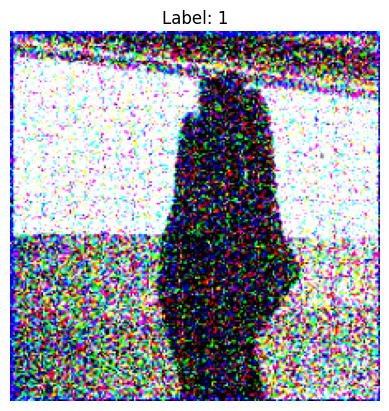

In [590]:
data_iter = iter(train_data)
images, labels = next(data_iter)

img = images[0]  # тензор [C, H, W]

img = img.permute(1, 2, 0).cpu().numpy()  # [H, W, C]
img = img * 0.5 + 0.5
img = np.clip(img, 0, 1)

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f'Label: {labels[0].item()}')
plt.axis('off')
plt.show()


In [591]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'accuracy'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=5, 
    save_best=True,
    metric=metric
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

model, res_lst, res_lst_val = train_model_with_callbacks(
    model, device, train_data, train_size, train_data_val,
    optimizer, loss_func, epochs=50,
    metric=metric,
    callbacks=[earlystop_cb],
    lr_scheduler=scheduler
)


Epoch [1/50] | accuracy_train=0.347, accuracy_val=0.350


Epoch [2/50] | accuracy_train=0.588, accuracy_val=0.500


Epoch [3/50] | accuracy_train=0.623, accuracy_val=0.588


Epoch [4/50] | accuracy_train=0.715, accuracy_val=0.667


Epoch [5/50] | accuracy_train=0.780, accuracy_val=0.675


...

Epoch [17/50] | accuracy_train=0.916, accuracy_val=0.871
EarlyStopping: no improvement for 1 epochs


Epoch [18/50] | accuracy_train=0.926, accuracy_val=0.883
EarlyStopping: no improvement for 2 epochs


Epoch [19/50] | accuracy_train=0.935, accuracy_val=0.867
EarlyStopping: no improvement for 3 epochs


Epoch [20/50] | accuracy_train=0.931, accuracy_val=0.879
EarlyStopping: no improvement for 4 epochs


Epoch [21/50] | accuracy_train=0.936, accuracy_val=0.867
EarlyStopping: no improvement for 5 epochs
EarlyStopping: stopping training at epoch 21


0.8933333333333333


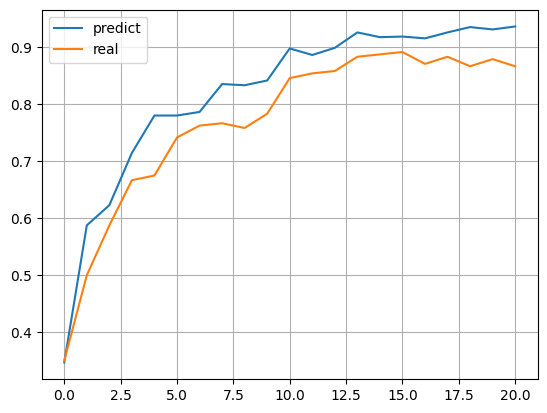

In [592]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

## Использование предобученных моделей нейронных сетей

### Использование моделей нейронной сети из библиотеки torchvision

#### ShuffleNet

In [598]:
model = torchvision.models.shufflenet_v2_x1_5().to(device)

In [599]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()

In [600]:
transforms = A.Compose(
    [
        A.Affine(
            translate_percent={"x": (-0.15, 0.15), "y": (-0.15, 0.15)},
            scale=(0.85, 1.15),
            rotate=(-15, 15),
            p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.OneOf([
            A.MotionBlur(p=0.2),
            A.OpticalDistortion(p=0.2),
            A.GaussNoise(p=0.2)
        ], p=1),
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

train_size = 0.8
batch_size = 100
album = True

In [601]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [602]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'accuracy'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=5, 
    save_best=True,
    metric=metric
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

model, res_lst, res_lst_val = train_model_with_callbacks(
    model, device, train_data, train_size, train_data_val,
    optimizer, loss_func, epochs=50,
    metric=metric,
    callbacks=[earlystop_cb],
    lr_scheduler=scheduler
)


Epoch [1/50] | accuracy_train=0.327, accuracy_val=0.358


Epoch [2/50] | accuracy_train=0.327, accuracy_val=0.358
EarlyStopping: no improvement for 1 epochs


Epoch [3/50] | accuracy_train=0.340, accuracy_val=0.304
EarlyStopping: no improvement for 2 epochs


Epoch [4/50] | accuracy_train=0.495, accuracy_val=0.492


Epoch [5/50] | accuracy_train=0.465, accuracy_val=0.425
EarlyStopping: no improvement for 1 epochs


...

Epoch [16/50] | accuracy_train=0.931, accuracy_val=0.921
EarlyStopping: no improvement for 1 epochs


Epoch [17/50] | accuracy_train=0.942, accuracy_val=0.958
EarlyStopping: no improvement for 2 epochs


Epoch [18/50] | accuracy_train=0.938, accuracy_val=0.942
EarlyStopping: no improvement for 3 epochs


Epoch [19/50] | accuracy_train=0.949, accuracy_val=0.946
EarlyStopping: no improvement for 4 epochs


Epoch [20/50] | accuracy_train=0.955, accuracy_val=0.950
EarlyStopping: no improvement for 5 epochs
EarlyStopping: stopping training at epoch 20


0.92


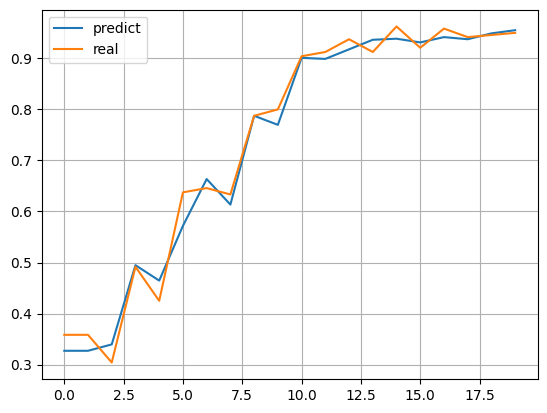

In [603]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### RegNet

In [604]:
model = torchvision.models.regnet_y_400mf().to(device)

In [605]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()

In [606]:
transforms = A.Compose(
    [
        A.Affine(
            translate_percent={"x": (-0.15, 0.15), "y": (-0.15, 0.15)},
            scale=(0.85, 1.15),
            rotate=(-15, 15),
            p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.OneOf([
            A.MotionBlur(p=0.2),
            A.OpticalDistortion(p=0.2),
            A.GaussNoise(p=0.2)
        ], p=1),
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

train_size = 0.8
batch_size = 100
album = True

In [607]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [608]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'accuracy'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=5, 
    save_best=True,
    metric=metric
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

model, res_lst, res_lst_val = train_model_with_callbacks(
    model, device, train_data, train_size, train_data_val,
    optimizer, loss_func, epochs=50,
    metric=metric,
    callbacks=[earlystop_cb],
    lr_scheduler=scheduler
)


Epoch [1/50] | accuracy_train=0.319, accuracy_val=0.392


Epoch [2/50] | accuracy_train=0.332, accuracy_val=0.396


Epoch [3/50] | accuracy_train=0.319, accuracy_val=0.392
EarlyStopping: no improvement for 1 epochs


Epoch [4/50] | accuracy_train=0.460, accuracy_val=0.492


Epoch [5/50] | accuracy_train=0.561, accuracy_val=0.575


...

Epoch [16/50] | accuracy_train=0.939, accuracy_val=0.946
EarlyStopping: no improvement for 1 epochs


Epoch [17/50] | accuracy_train=0.936, accuracy_val=0.938
EarlyStopping: no improvement for 2 epochs


Epoch [18/50] | accuracy_train=0.949, accuracy_val=0.958
EarlyStopping: no improvement for 3 epochs


Epoch [19/50] | accuracy_train=0.963, accuracy_val=0.933
EarlyStopping: no improvement for 4 epochs


Epoch [20/50] | accuracy_train=0.959, accuracy_val=0.946
EarlyStopping: no improvement for 5 epochs
EarlyStopping: stopping training at epoch 20


0.95


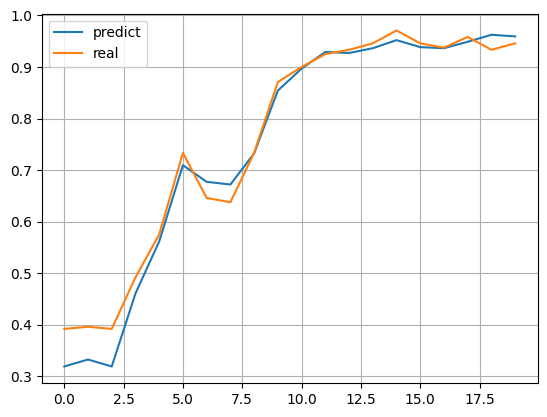

In [609]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Перенос обучения

#### ShuffleNet

In [610]:
weights = torchvision.models.ShuffleNet_V2_X1_5_Weights.DEFAULT
model = torchvision.models.shufflenet_v2_x1_5(weights=weights).to(device)

In [611]:
for param in model.conv1.parameters():
  param.requires_grad = False
for param in model.stage2.parameters():
  param.requires_grad = False
for param in model.stage3.parameters():
  param.requires_grad = False
for param in model.stage4.parameters():
  param.requires_grad = False
for param in model.conv5.parameters():
  param.requires_grad = False

In [612]:
num_features = model.fc.in_features 
model.fc = torch.nn.Linear(num_features, len(classes)).to(device)

In [613]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
loss_func = nn.CrossEntropyLoss()

In [614]:
transforms = A.Compose(
    [
        A.Affine(
            translate_percent={"x": (-0.15, 0.15), "y": (-0.15, 0.15)},
            scale=(0.85, 1.15),
            rotate=(-15, 15),
            p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.OneOf([
            A.MotionBlur(p=0.2),
            A.OpticalDistortion(p=0.2),
            A.GaussNoise(p=0.2)
        ], p=1),
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

train_size = 0.8
batch_size = 100
album = True

In [615]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [616]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'accuracy'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=5, 
    save_best=True,
    metric=metric
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

model, res_lst, res_lst_val = train_model_with_callbacks(
    model, device, train_data, train_size, train_data_val,
    optimizer, loss_func, epochs=50,
    metric=metric,
    callbacks=[earlystop_cb],
    lr_scheduler=scheduler
)


Epoch [1/50] | accuracy_train=0.592, accuracy_val=0.633


Epoch [2/50] | accuracy_train=0.793, accuracy_val=0.796


Epoch [3/50] | accuracy_train=0.851, accuracy_val=0.867


Epoch [4/50] | accuracy_train=0.834, accuracy_val=0.858
EarlyStopping: no improvement for 1 epochs


Epoch [5/50] | accuracy_train=0.853, accuracy_val=0.821
EarlyStopping: no improvement for 2 epochs


...

Epoch [9/50] | accuracy_train=0.864, accuracy_val=0.871
EarlyStopping: no improvement for 1 epochs


Epoch [10/50] | accuracy_train=0.872, accuracy_val=0.887
EarlyStopping: no improvement for 2 epochs


Epoch [11/50] | accuracy_train=0.873, accuracy_val=0.896
EarlyStopping: no improvement for 3 epochs


Epoch [12/50] | accuracy_train=0.885, accuracy_val=0.871
EarlyStopping: no improvement for 4 epochs


Epoch [13/50] | accuracy_train=0.885, accuracy_val=0.854
EarlyStopping: no improvement for 5 epochs
EarlyStopping: stopping training at epoch 13


0.89


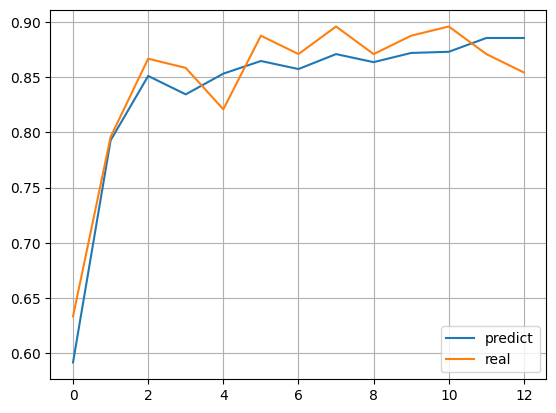

In [617]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### RegNet

In [618]:
weights = torchvision.models.RegNet_Y_400MF_Weights.DEFAULT
model = torchvision.models.regnet_y_400mf(weights=weights).to(device)

In [619]:
for param in model.stem.parameters():
  param.requires_grad = False
for param in model.trunk_output.parameters():
  param.requires_grad = False

In [620]:
num_features = model.fc.in_features
model.fc = torch.nn.Linear(num_features, len(classes)).to(device)

In [621]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
loss_func = nn.CrossEntropyLoss()

In [622]:
transforms = A.Compose(
    [
        A.Affine(
            translate_percent={"x": (-0.15, 0.15), "y": (-0.15, 0.15)},
            scale=(0.85, 1.15),
            rotate=(-15, 15),
            p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.OneOf([
            A.MotionBlur(p=0.2),
            A.OpticalDistortion(p=0.2),
            A.GaussNoise(p=0.2)
        ], p=1),
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

train_size = 0.8
batch_size = 100
album = True

In [623]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [624]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'accuracy'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=5, 
    save_best=True,
    metric=metric
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

model, res_lst, res_lst_val = train_model_with_callbacks(
    model, device, train_data, train_size, train_data_val,
    optimizer, loss_func, epochs=50,
    metric=metric,
    callbacks=[earlystop_cb],
    lr_scheduler=scheduler
)


Epoch [1/50] | accuracy_train=0.472, accuracy_val=0.350


Epoch [2/50] | accuracy_train=0.613, accuracy_val=0.567


Epoch [3/50] | accuracy_train=0.671, accuracy_val=0.650


Epoch [4/50] | accuracy_train=0.700, accuracy_val=0.783


Epoch [5/50] | accuracy_train=0.689, accuracy_val=0.683
EarlyStopping: no improvement for 1 epochs


...

Epoch [9/50] | accuracy_train=0.794, accuracy_val=0.775
EarlyStopping: no improvement for 1 epochs


Epoch [10/50] | accuracy_train=0.808, accuracy_val=0.779
EarlyStopping: no improvement for 2 epochs


Epoch [11/50] | accuracy_train=0.807, accuracy_val=0.800
EarlyStopping: no improvement for 3 epochs


Epoch [12/50] | accuracy_train=0.787, accuracy_val=0.796
EarlyStopping: no improvement for 4 epochs


Epoch [13/50] | accuracy_train=0.808, accuracy_val=0.779
EarlyStopping: no improvement for 5 epochs
EarlyStopping: stopping training at epoch 13


0.7433333333333333


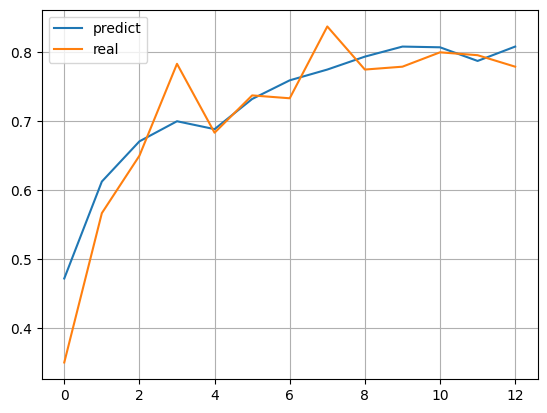

In [625]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

### Fine tuning

#### Базовые функции

In [229]:
def get_submodule_names(module, max_depth=2, prefix=''):
    # вывод списка названий суб-блоков НН 
    if max_depth == 0:
        return []
    
    names = []
    for name, child in module.named_children():
        if (name == 'fc') or ('pool' in name):
            continue
        
        full_name = f"{prefix}{name}" if prefix == '' else f"{prefix}.{name}"
        
        # Проверяем, есть ли у ребенка trainable параметры
        children = list(child.named_children())
        if max_depth > 1 and children:
            # Есть дети — рекурсивно ищем в них
            names.extend(get_submodule_names(child, max_depth - 1, full_name))
        else:
            # Дети есть, но max_depth исчерпан, или детей нет — добавляем этот модуль
            names.append(full_name)

    return names

In [270]:
def get_submodule_by_name(model, submodule_name):
    # вывод блока НН по его названию
    parts = submodule_name.split('.')
    module = model
    for part in parts:
        module = getattr(module, part, None)
    return module

# Функция разморозки блока
def unfreeze_block(model, block_name):
    block = get_submodule_by_name(model, block_name)
    if block is None:
        return False

    # Проверка, разморожен ли уже блок
    any_frozen = any(not param.requires_grad for param in block.parameters())
    if not any_frozen:
        return False

    for param in block.parameters():
        param.requires_grad = True
    return True  


# Функция размораживания следующих блоков по номеру эпохи
def gradual_unfreeze(epoch, freeze_order, unfreeze_step=5):
    idx = epoch // unfreeze_step - 1
    if 0 <= idx < len(freeze_order):
        # вывод при успешной разморозке
        if unfreeze_block(model, freeze_order[idx]):
            print(f'Unfroze block: {freeze_order[idx]} at epoch {epoch}')

In [ ]:
def train_model_with_callbacks_finetune(
    model, device, 
    train_data, train_data_val,
    loss_func, epochs,
    freeze_order, unfreeze_step=5,
    opt_lr=0.001, lr_sch_step=5, lr_sch_gamma=0.1,
    metric='accuracy',
    callbacks=[],
):
    model.to(device)
    res_lst_val = []
    res_lst = []

    for epoch in range(epochs):
        model.train()
        loss_mean = 0
        lm_count = 0
        train_tqdm = tqdm(train_data, leave=False)

        gradual_unfreeze(epoch, freeze_order, unfreeze_step)
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=opt_lr)
        lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=lr_sch_step, gamma=lr_sch_gamma)

        for x_train, y_train in train_tqdm:
            x_train = x_train.to(device)
            y_train = y_train.to(device)

            predict = model(x_train)
            loss = loss_func(predict, y_train)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            lm_count += 1
            loss_mean = loss.item() / lm_count + loss_mean * (1 - 1 / lm_count)
            train_tqdm.set_description(f"Epoch [{epoch+1}/{epochs}], loss: {loss_mean:.4f}")

        # метрики на обучении и валидации
        if metric == 'accuracy':
            train_res = accuracy_model(model, device, train_data)
            val_res = accuracy_model(model, device, train_data_val)
        elif metric == 'loss':
            train_res = loss_mean
            val_res = loss_model(model, loss_func, train_data_val)

        res_lst.append(train_res)
        res_lst_val.append(val_res)

        print(f'Epoch [{epoch+1}/{epochs}] | {metric}_train={train_res:.3f}, {metric}_val={val_res:.3f}')

        # callbacks
        early_stop = do_callbacks(model, callbacks, epoch, val_res)
        if early_stop:
            return model, res_lst, res_lst_val
        
        # scheduler
        update_scheduler(lr_scheduler, val_res)
    return model, res_lst, res_lst_val

#### ShuffleNet

In [262]:
weights = torchvision.models.ShuffleNet_V2_X1_5_Weights.DEFAULT
model = torchvision.models.shufflenet_v2_x1_5(weights=weights).to(device)

In [263]:
summary(model=model,
        input_size=(100, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ShuffleNetV2 (ShuffleNetV2)              [100, 3, 224, 224]   [100, 1000]          --                   True
├─Sequential (conv1)                     [100, 3, 224, 224]   [100, 24, 112, 112]  --                   True
│    └─Conv2d (0)                        [100, 3, 224, 224]   [100, 24, 112, 112]  648                  True
│    └─BatchNorm2d (1)                   [100, 24, 112, 112]  [100, 24, 112, 112]  48                   True
│    └─ReLU (2)                          [100, 24, 112, 112]  [100, 24, 112, 112]  --                   --
├─MaxPool2d (maxpool)                    [100, 24, 112, 112]  [100, 24, 56, 56]    --                   --
├─Sequential (stage2)                    [100, 24, 56, 56]    [100, 176, 28, 28]   --                   True
│    └─InvertedResidual (0)              [100, 24, 56, 56]    [100, 176, 28, 28]   --                   True
│    │    └─Sequen

In [264]:
for param in model.parameters():
    param.requires_grad = False

# Разморозить fc слой
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(classes)).to(device)
for param in model.fc.parameters():
    param.requires_grad = True

In [265]:
loss_func = nn.CrossEntropyLoss()
epochs = 50

freeze_order = get_submodule_names(model, max_depth=1)[::-1]
print(len(freeze_order), freeze_order)

5 ['conv5', 'stage4', 'stage3', 'stage2', 'conv1']


In [266]:
transforms = A.Compose(
    [
        A.Affine(
            translate_percent={"x": (-0.15, 0.15), "y": (-0.15, 0.15)},
            scale=(0.85, 1.15),
            rotate=(-15, 15),
            p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.OneOf([
            A.MotionBlur(p=0.2),
            A.OpticalDistortion(p=0.2),
            A.GaussNoise(p=0.2)
        ], p=1),
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

train_size = 0.8
batch_size = 100
album = True

In [267]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [268]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'accuracy'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=5, 
    save_best=True,
    metric=metric
)

model, res_lst, res_lst_val = train_model_with_callbacks_finetune(
    model, device, train_data, train_data_val,
    loss_func, epochs,
    freeze_order, unfreeze_step=5,
    opt_lr=0.001, lr_sch_step=2, lr_sch_gamma=0.1,
    metric=metric,
    callbacks=[earlystop_cb]
)


Epoch [1/50] | accuracy_train=0.733, accuracy_val=0.729


Epoch [2/50] | accuracy_train=0.833, accuracy_val=0.858


Epoch [3/50] | accuracy_train=0.842, accuracy_val=0.850
EarlyStopping: no improvement for 1 epochs


Epoch [4/50] | accuracy_train=0.827, accuracy_val=0.838
EarlyStopping: no improvement for 2 epochs


Epoch [5/50] | accuracy_train=0.852, accuracy_val=0.846
EarlyStopping: no improvement for 3 epochs


...

Epoch [16/50] | accuracy_train=0.830, accuracy_val=0.858
EarlyStopping: no improvement for 1 epochs


Epoch [17/50] | accuracy_train=0.980, accuracy_val=0.975
EarlyStopping: no improvement for 2 epochs


Epoch [18/50] | accuracy_train=0.989, accuracy_val=0.992
EarlyStopping: no improvement for 3 epochs


Epoch [19/50] | accuracy_train=0.991, accuracy_val=0.988
EarlyStopping: no improvement for 4 epochs


Epoch [20/50] | accuracy_train=0.981, accuracy_val=0.996
EarlyStopping: no improvement for 5 epochs
True
EarlyStopping: stopping training at epoch 20
early_stop True


1.0


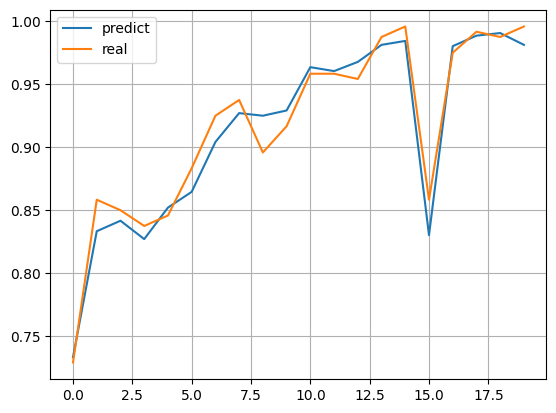

In [269]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)

#### RegNet

In [271]:
weights = torchvision.models.RegNet_Y_400MF_Weights.DEFAULT
model = torchvision.models.regnet_y_400mf(weights=weights).to(device)

In [272]:
summary(model=model,
        input_size=(100, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
RegNet (RegNet)                                              [100, 3, 224, 224]   [100, 1000]          --                   True
├─SimpleStemIN (stem)                                        [100, 3, 224, 224]   [100, 32, 112, 112]  --                   True
│    └─Conv2d (0)                                            [100, 3, 224, 224]   [100, 32, 112, 112]  864                  True
│    └─BatchNorm2d (1)                                       [100, 32, 112, 112]  [100, 32, 112, 112]  64                   True
│    └─ReLU (2)                                              [100, 32, 112, 112]  [100, 32, 112, 112]  --                   --
├─Sequential (trunk_output)                                  [100, 32, 112, 112]  [100, 440, 7, 7]     --                   True
│    └─AnyStage (block1)                                     [100, 32, 112, 112]  [100, 48, 56

In [273]:
for param in model.parameters():
    param.requires_grad = False

# Разморозить fc слой
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(classes)).to(device)
for param in model.fc.parameters():
    param.requires_grad = True

In [274]:
summary(model=model,
        input_size=(100, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
RegNet (RegNet)                                              [100, 3, 224, 224]   [100, 3]             --                   Partial
├─SimpleStemIN (stem)                                        [100, 3, 224, 224]   [100, 32, 112, 112]  --                   False
│    └─Conv2d (0)                                            [100, 3, 224, 224]   [100, 32, 112, 112]  (864)                False
│    └─BatchNorm2d (1)                                       [100, 32, 112, 112]  [100, 32, 112, 112]  (64)                 False
│    └─ReLU (2)                                              [100, 32, 112, 112]  [100, 32, 112, 112]  --                   --
├─Sequential (trunk_output)                                  [100, 32, 112, 112]  [100, 440, 7, 7]     --                   False
│    └─AnyStage (block1)                                     [100, 32, 112, 112]  [100,

In [275]:
loss_func = nn.CrossEntropyLoss()
epochs = 50

freeze_order = get_submodule_names(model, max_depth=3)[::-1]
print(freeze_order)

['trunk_output.block4.block4-5', 'trunk_output.block4.block4-4', 'trunk_output.block4.block4-3', 'trunk_output.block4.block4-2', 'trunk_output.block4.block4-1', 'trunk_output.block4.block4-0', 'trunk_output.block3.block3-5', 'trunk_output.block3.block3-4', 'trunk_output.block3.block3-3', 'trunk_output.block3.block3-2', 'trunk_output.block3.block3-1', 'trunk_output.block3.block3-0', 'trunk_output.block2.block2-2', 'trunk_output.block2.block2-1', 'trunk_output.block2.block2-0', 'trunk_output.block1.block1-0', 'stem.2', 'stem.1', 'stem.0']


In [276]:
transforms = A.Compose(
    [
        A.Affine(
            translate_percent={"x": (-0.15, 0.15), "y": (-0.15, 0.15)},
            scale=(0.85, 1.15),
            rotate=(-15, 15),
            p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.OneOf([
            A.MotionBlur(p=0.2),
            A.OpticalDistortion(p=0.2),
            A.GaussNoise(p=0.2)
        ], p=1),
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

train_size = 0.8
batch_size = 100
album = True

In [277]:
train_data, train_data_val, test_data = split_data(transforms, train_size=train_size, 
                                                   batch_size=batch_size, album=album)

In [279]:
models_path = 'models'
chck_p_path = os.path.join(models_path, 'model_epoch-{epoch}_{metric}-{metric_val:.4f}.pt')
erly_st_path = os.path.join(models_path, 'best_model_{metric}-{metric_val:.4f}.pt')

metric = 'accuracy'

checkpoint_cb = ModelCheckpoint(
    filepath=chck_p_path, 
    save_best_only=True, 
    save_step=3,
    metric=metric
)

earlystop_cb = EarlyStopping(
    filepath=erly_st_path, 
    patience=5, 
    save_best=True,
    metric=metric
)

model, res_lst, res_lst_val = train_model_with_callbacks_finetune(
    model, device, train_data, train_data_val,
    loss_func, epochs,
    freeze_order, unfreeze_step=4,
    opt_lr=0.001, lr_sch_step=2, lr_sch_gamma=0.1,
    metric=metric,
    callbacks=[earlystop_cb]
)


Epoch [1/50] | accuracy_train=0.482, accuracy_val=0.492


Epoch [2/50] | accuracy_train=0.608, accuracy_val=0.608


Epoch [3/50] | accuracy_train=0.689, accuracy_val=0.629


Epoch [4/50] | accuracy_train=0.694, accuracy_val=0.679


  0%|          | 0/10 [00:00<?, ?it/s]

...

Epoch [36/50] | accuracy_train=0.960, accuracy_val=0.958
EarlyStopping: no improvement for 3 epochs


  0%|          | 0/10 [00:00<?, ?it/s]

Unfroze block: trunk_output.block3.block3-3 at epoch 36


Epoch [37/50] | accuracy_train=0.988, accuracy_val=0.967
EarlyStopping: no improvement for 4 epochs


Epoch [38/50] | accuracy_train=0.985, accuracy_val=0.983
EarlyStopping: no improvement for 5 epochs
True
EarlyStopping: stopping training at epoch 38
early_stop True


0.98


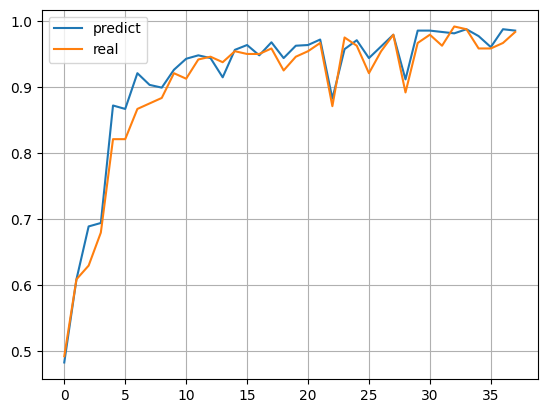

In [281]:
print(accuracy_model(model, device, test_data))
show_loss(res_lst, res_lst_val)